In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


##Phân tích dữ liệu thiếu

--- Đang tải dữ liệu ---
Kích thước tập dữ liệu: (5630, 20)

Số dòng dữ liệu thiếu mỗi cột:
 Tenure                         264
WarehouseToHome                251
HourSpendOnApp                 255
OrderAmountHikeFromlastYear    265
CouponUsed                     256
OrderCount                     258
DaySinceLastOrder              307
dtype: int64

Phần trăm dữ liệu thiếu mỗi cột (%):
 Tenure                         4.689165
WarehouseToHome                4.458259
HourSpendOnApp                 4.529307
OrderAmountHikeFromlastYear    4.706927
CouponUsed                     4.547069
OrderCount                     4.582593
DaySinceLastOrder              5.452931
dtype: float64


/tmp/ipykernel_2007/4152155814.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data_counts.values, y=missing_data_counts.index, palette='viridis')


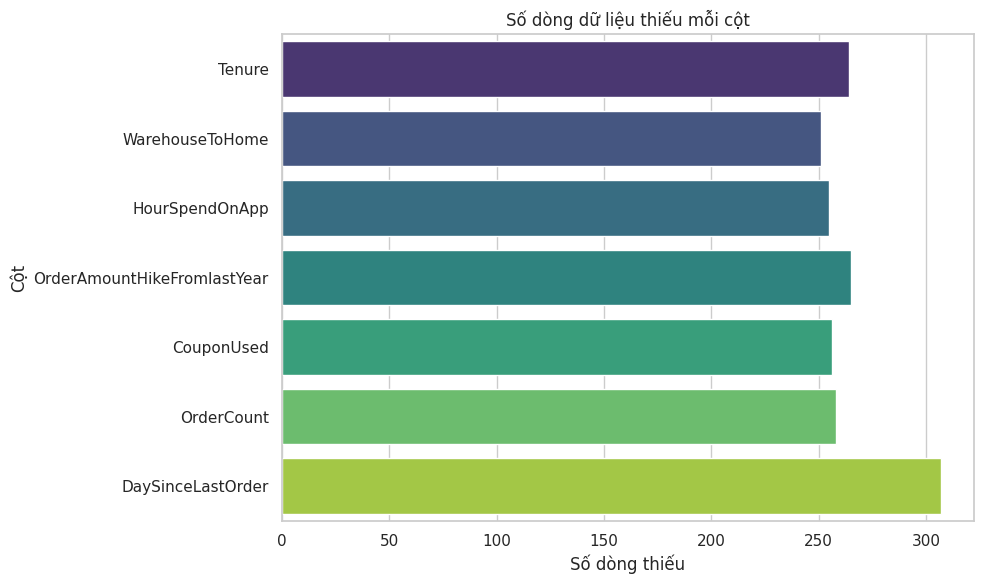

/tmp/ipykernel_2007/4152155814.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data_pct.values, y=missing_data_pct.index, palette='magma')


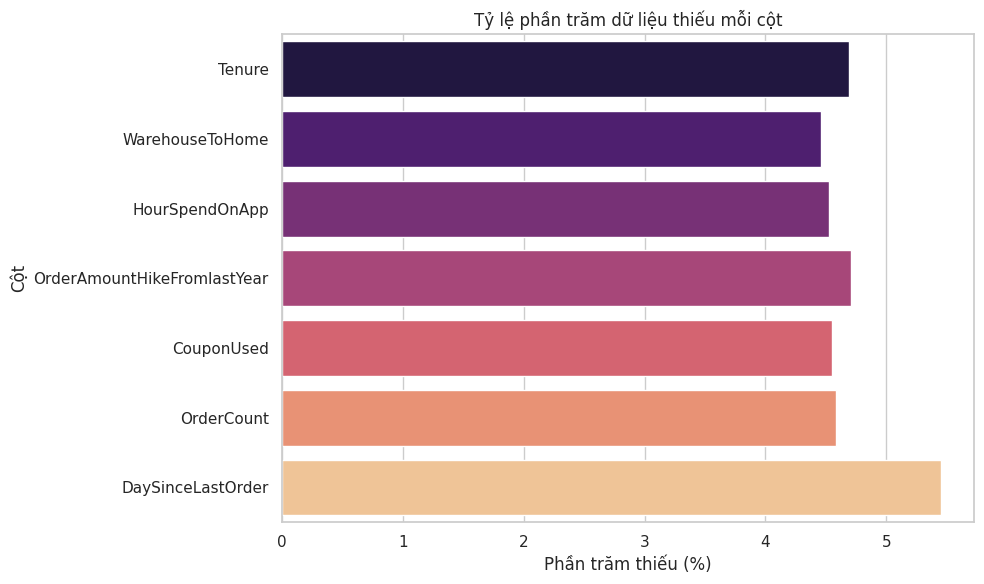

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

def analyze_missing_data(file_path):
    print("--- Đang tải dữ liệu ---")
    df = pd.read_csv(file_path)

    # 1. KIỂM TRA TỔNG QUAN
    print(f"Kích thước tập dữ liệu: {df.shape}")

    # 2. XỬ LÝ DỮ LIỆU THIẾU (MISSING VALUES)
    # Kiểm tra số dòng dữ liệu thiếu
    null_counts = df.isnull().sum()
    missing_data_counts = null_counts[null_counts > 0]
    print("\nSố dòng dữ liệu thiếu mỗi cột:\n", missing_data_counts)

    # Kiểm tra phần trăm dữ liệu thiếu
    null_pct = (df.isnull().sum() / len(df) * 100)
    missing_data_pct = null_pct[null_pct > 0]
    print("\nPhần trăm dữ liệu thiếu mỗi cột (%):\n", missing_data_pct)

    # Biểu đồ 1: Số dòng dữ liệu thiếu mỗi cột (Ngang)
    if not missing_data_counts.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(x=missing_data_counts.values, y=missing_data_counts.index, palette='viridis')
        plt.title('Số dòng dữ liệu thiếu mỗi cột')
        plt.xlabel('Số dòng thiếu')
        plt.ylabel('Cột')
        plt.tight_layout()
        plt.show()
    else:
        print("\nKhông có dữ liệu thiếu nào được tìm thấy.")

    # Biểu đồ 2: Tỷ lệ phần trăm dữ liệu thiếu mỗi cột (Ngang)
    if not missing_data_pct.empty:
        plt.figure(figsize=(10, 6))
        sns.barplot(x=missing_data_pct.values, y=missing_data_pct.index, palette='magma')
        plt.title('Tỷ lệ phần trăm dữ liệu thiếu mỗi cột')
        plt.xlabel('Phần trăm thiếu (%)')
        plt.ylabel('Cột')
        plt.tight_layout()
        plt.show()

analyze_missing_data('/content/drive/MyDrive/Colab Notebooks/data/E Commerce Dataset.csv')

##Làm sạch data

In [ ]:
def clean_data(file_path):
    print("--- Đang tải dữ liệu ---")
    df = pd.read_csv(file_path)

    # Chiến lược:
    # - Điền giá trị trung vị (median) cho các biến số để tránh ảnh hưởng bởi giá trị ngoại lệ
    cols_with_missing = ['WarehouseToHome', 'HourSpendOnApp']

    # Tính toán và in ra giá trị trung vị cho mỗi cột trước khi điền
    print("\nGiá trị trung vị của các cột có dữ liệu thiếu:")
    median_values = {}
    for col in cols_with_missing:
        median_values[col] = df[col].median()
        print(f'{col}: {median_values[col]}')

    # Điền giá trị thiếu bằng giá trị trung vị đã tính
    for col in cols_with_missing:
        df[col] = df[col].fillna(median_values[col])

    # 3. CHUẨN HÓA CÁC GIÁ TRỊ PHÂN LOẠI (CATEGORICAL DATA)
    # Kiểm tra các giá trị duy nhất trong các cột phân loại
    # Sửa 'Mobile Phone' và 'Phone' thành cùng một loại
    df['PreferredLoginDevice'] = df['PreferredLoginDevice'].replace('Phone', 'Mobile Phone')

    # Sửa 'CC' thành 'Credit Card' và 'COD' thành 'Cash on Delivery'
    df['PreferredPaymentMode'] = df['PreferredPaymentMode'].replace({
        'CC': 'Credit Card',
        'COD': 'Cash on Delivery'
    })

    # Sửa 'Mobile' thành 'Mobile Phone' trong PreferedOrderCat
    df['PreferedOrderCat'] = df['PreferedOrderCat'].replace('Mobile', 'Mobile Phone')

    # 4. XỬ LÝ GIÁ TRỊ NGOẠI LỆ (OUTLIERS)
    # Ví dụ: WarehouseToHome có giá trị lên tới 120km (có thể là lỗi hoặc quá xa)
    # Ở đây chúng ta giữ lại nhưng cần lưu ý khi phân tích

    print("\n--- Làm sạch hoàn tất ---")
    return df

df_cleaned = clean_data('/content/drive/MyDrive/Colab Notebooks/data/E Commerce Dataset.csv')
df_cleaned.to_csv('E_Comm_Cleaned.csv', index=False)

--- Đang tải dữ liệu ---

Giá trị trung vị của các cột có dữ liệu thiếu:
WarehouseToHome: 14.0
HourSpendOnApp: 3.0

--- Làm sạch hoàn tất ---


### Kiểm tra các giá trị duy nhất sau khi chuẩn hóa

Đoạn mã này hiển thị các giá trị duy nhất của các cột phân loại sau khi hàm `clean_data` đã được áp dụng, để xác nhận việc chuẩn hóa.

In [ ]:
# Tải và làm sạch dữ liệu bằng hàm đã định nghĩa
FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/data/E Commerce Dataset.csv'
df = pd.read_csv(FILE_PATH)

print("\nCác giá trị duy nhất trong 'PreferredLoginDevice' trước khi làm sạch:")
print(df['PreferredLoginDevice'].unique())

print("\nCác giá trị duy nhất trong 'PreferredPaymentMode' trước khi làm sạch:")
print(df['PreferredPaymentMode'].unique())

print("\nCác giá trị duy nhất trong 'PreferedOrderCat' trước khi làm sạch:")
print(df['PreferedOrderCat'].unique())



Các giá trị duy nhất trong 'PreferredLoginDevice' trước khi làm sạch:
['Mobile Phone' 'Phone' 'Computer']

Các giá trị duy nhất trong 'PreferredPaymentMode' trước khi làm sạch:
['Debit Card' 'UPI' 'CC' 'Cash on Delivery' 'E wallet' 'COD' 'Credit Card']

Các giá trị duy nhất trong 'PreferedOrderCat' trước khi làm sạch:
['Laptop & Accessory' 'Mobile' 'Mobile Phone' 'Others' 'Fashion' 'Grocery']


In [ ]:
# Ensure we have the cleaned DataFrame
cleaned_df = clean_data(FILE_PATH)

# Select numerical columns
numerical_cols = cleaned_df.select_dtypes(include=['number'])

print("\nGiá trị trung bình của các cột số sau khi làm sạch:")
print(numerical_cols.mean())


--- Đang tải dữ liệu ---
Tenure: 9.0
WarehouseToHome: 14.0
HourSpendOnApp: 3.0
OrderAmountHikeFromlastYear: 15.0
CouponUsed: 1.0
OrderCount: 2.0
DaySinceLastOrder: 3.0

--- Làm sạch hoàn tất ---

Giá trị trung bình của các cột số sau khi làm sạch:
CustomerID                     52815.500000
Churn                              0.168384
Tenure                            10.134103
CityTier                           1.654707
WarehouseToHome                   15.566785
HourSpendOnApp                     2.934636
NumberOfDeviceRegistered           3.688988
SatisfactionScore                  3.066785
NumberOfAddress                    4.214032
Complain                           0.284902
OrderAmountHikeFromlastYear       15.674600
CouponUsed                         1.716874
OrderCount                         2.961812
DaySinceLastOrder                  4.459325
CashbackAmount                   177.221492
dtype: float64


In [ ]:
def exploratory_data_analysis(df):
    print("\n--- Bắt đầu phân tích dữ liệu (EDA) ---")

    # Biểu đồ 1: Tỷ lệ Churn
    plt.figure(figsize=(6, 6))
    df['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
    plt.title('Tỷ lệ giữa khách hàng rời bỏ (Churn) vs Ở lại')
    plt.show()

    # Biểu đồ 2: Mối liên hệ giữa Tenure (Thâm niên) và Churn
    plt.figure(figsize=(10, 5))
    sns.histplot(data=df, x='Tenure', hue='Churn', kde=True, element="step")
    plt.title('Phân phối thâm niên khách hàng theo tình trạng Churn')
    plt.show()

    # Biểu đồ 3: Khiếu nại (Complain) và Churn
    plt.figure(figsize=(8, 5))
    sns.countplot(data=df, x='Complain', hue='Churn')
    plt.title('Ảnh hưởng của việc Khiếu nại đến tỷ lệ rời bỏ')
    plt.show()

    # Biểu đồ 4: Ma trận tương quan (Correlation Matrix)
    plt.figure(figsize=(12, 10))
    # Chỉ lấy các cột số để tính tương quan
    numeric_df = df.select_dtypes(include=[np.number])
    sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Ma trận tương quan giữa các biến số')
    plt.show()

    # Biểu đồ 5, 6, 7: Tỷ lệ Churn theo từng nhóm cho các đặc trưng phân loại
    categorical_features_for_churn = [
        'PreferredLoginDevice',
        'PreferredPaymentMode',
        'PreferedOrderCat'
    ]

    print("\n--- Phân tích tỷ lệ rời bỏ theo các đặc trưng phân loại ---")

    fig, axes = plt.subplots(3, 1, figsize=(10, 15))

    for i, col in enumerate(categorical_features_for_churn):
        # Vẽ biểu đồ đếm số lượng, phân tách theo trạng thái Churn
        sns.countplot(data=df, y=col, hue='Churn', ax=axes[i], palette='viridis')
        axes[i].set_title(f'Phân tích Churn theo {col}')
        axes[i].set_xlabel('Số lượng khách hàng')
        axes[i].set_ylabel('')

    plt.tight_layout()
    plt.show()

    # Biểu đồ cột: Mối quan hệ giữa Churn và Tenure
    print("\n--- Tỷ lệ Churn theo nhóm Thời gian gắn bó ---")
    # Binning Tenure for better visualization
    df['Tenure_Group'] = pd.cut(df['Tenure'], bins=[0, 1, 3, 6, 12, 24, df['Tenure'].max() + 1],
                                labels=['0-1m', '1-3m', '3-6m', '6-12m', '12-24m', '24m+'], right=False)

    churn_rate_by_tenure = df.groupby('Tenure_Group')['Churn'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Tenure_Group', y='Churn', data=churn_rate_by_tenure, palette='coolwarm')
    plt.title('Tỷ lệ Churn theo nhóm Thời gian gắn bó')
    plt.xlabel('Thời gian gắn bó')
    plt.ylabel('Tỷ lệ rời bỏ')
    plt.tight_layout()
    plt.show()

    # Biểu đồ đường: Mối quan hệ giữa SatisfactionScore và Churn
    print("\n--- Tỷ lệ Churn theo Mức độ hài lòng ---")
    churn_rate_by_satisfaction = df.groupby('SatisfactionScore')['Churn'].mean().reset_index()

    plt.figure(figsize=(10, 6))
    sns.lineplot(data=churn_rate_by_satisfaction, x='SatisfactionScore', y='Churn', marker='o')
    plt.title('Tỷ lệ Churn theo Mức độ hài lòng')
    plt.xlabel('Mức độ hài lòng')
    plt.ylabel('Tỷ lệ rời bỏ')
    plt.xticks(sorted(df['SatisfactionScore'].unique()))
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_2007/1330338410.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data_counts.index, y=missing_data_counts.values, palette='viridis')


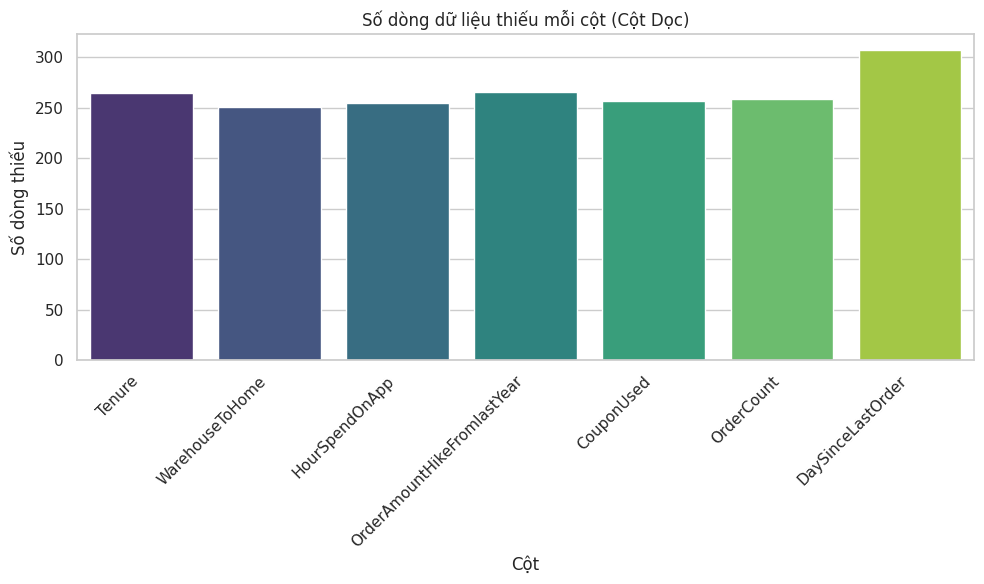

/tmp/ipykernel_2007/1330338410.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data_pct.values, y=missing_data_pct.index, palette='magma')


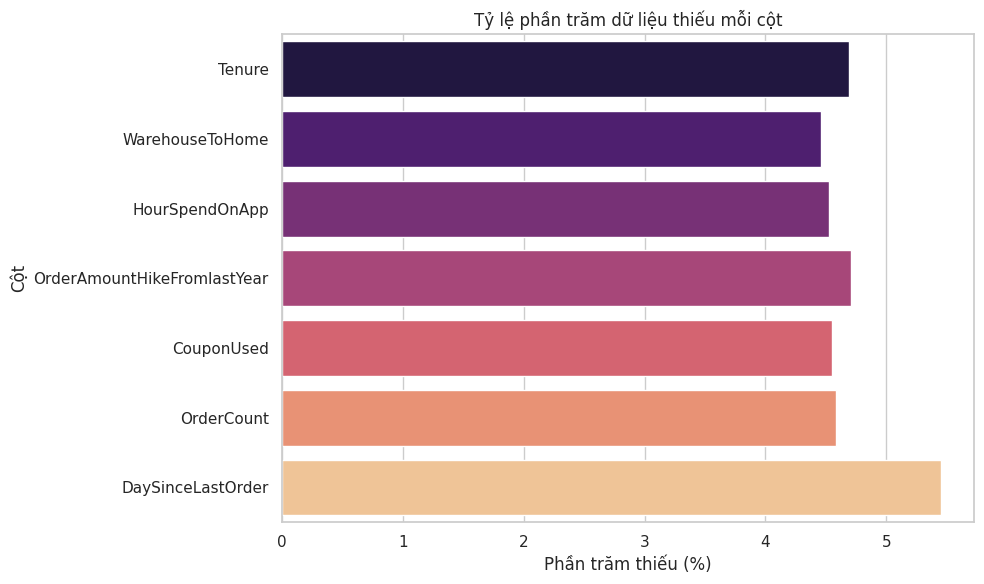

In [ ]:
# 1. Tính toán số dòng dữ liệu thiếu và phần trăm
null_counts = df.isnull().sum()
missing_data_counts = null_counts[null_counts > 0]

null_pct = (df.isnull().sum() / len(df) * 100)
missing_data_pct = null_pct[null_pct > 0]

# 2. Biểu đồ cột dọc: Số dòng dữ liệu thiếu mỗi cột
if not missing_data_counts.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data_counts.index, y=missing_data_counts.values, palette='viridis')
    plt.title('Số dòng dữ liệu thiếu mỗi cột (Cột Dọc)')
    plt.xlabel('Cột')
    plt.ylabel('Số dòng thiếu')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu thiếu nào để hiển thị biểu đồ số dòng.")

# 3. Biểu đồ cột ngang: Tỷ lệ phần trăm dữ liệu thiếu mỗi cột
if not missing_data_pct.empty:
    plt.figure(figsize=(10, 6))
    sns.barplot(x=missing_data_pct.values, y=missing_data_pct.index, palette='magma')
    plt.title('Tỷ lệ phần trăm dữ liệu thiếu mỗi cột')
    plt.xlabel('Phần trăm thiếu (%)')
    plt.ylabel('Cột')
    plt.tight_layout()
    plt.show()
else:
    print("Không có dữ liệu thiếu nào để hiển thị biểu đồ phần trăm.")

--- Đang tải dữ liệu ---

Giá trị trung vị của các cột có dữ liệu thiếu:
WarehouseToHome: 14.0
HourSpendOnApp: 3.0

--- Làm sạch hoàn tất ---

--- Bắt đầu phân tích dữ liệu (EDA) ---


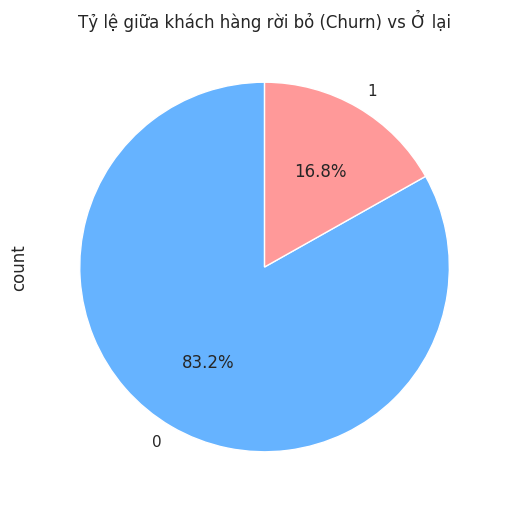

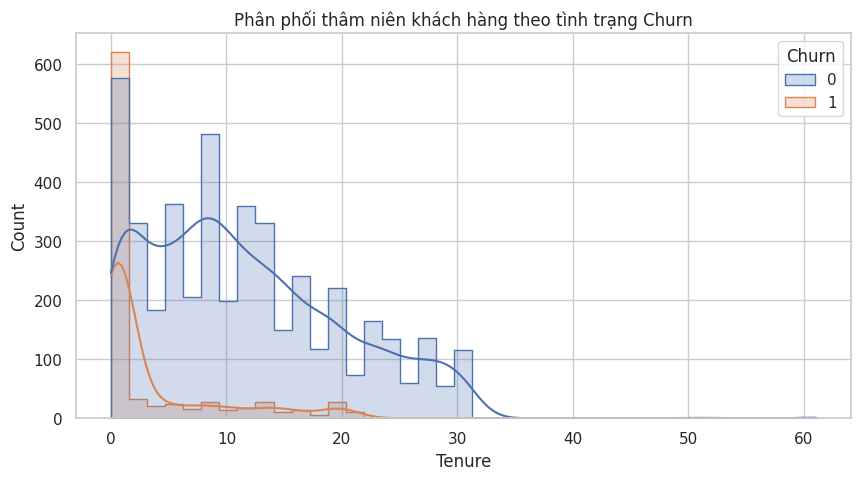

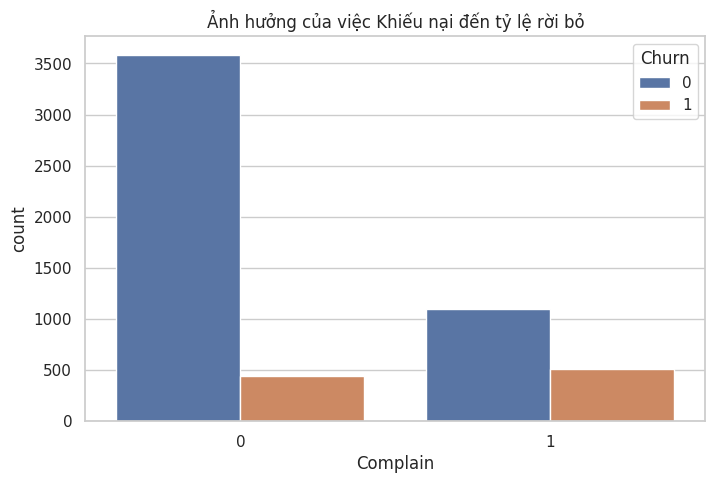

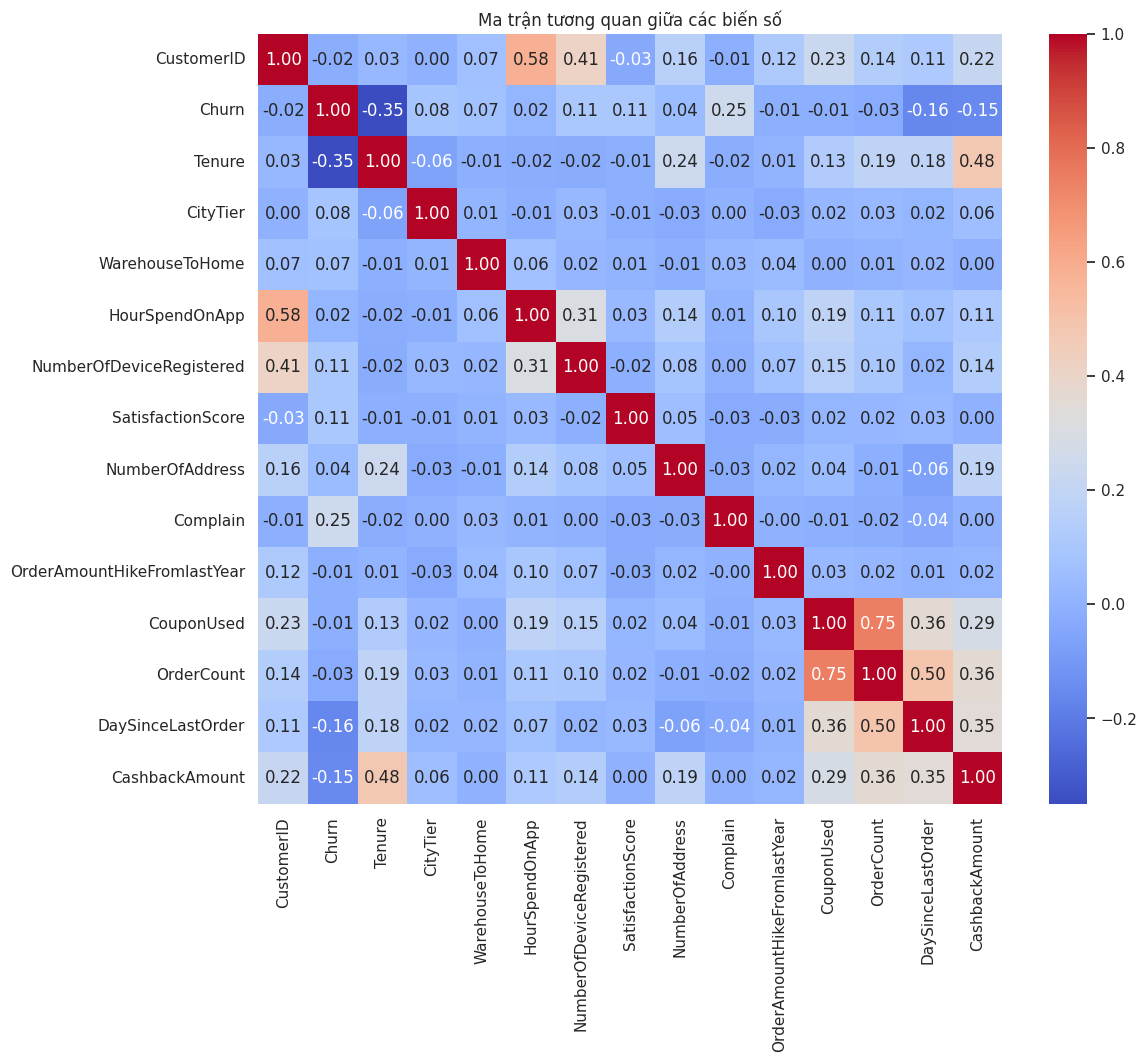


--- Phân tích tỷ lệ rời bỏ theo các đặc trưng phân loại ---


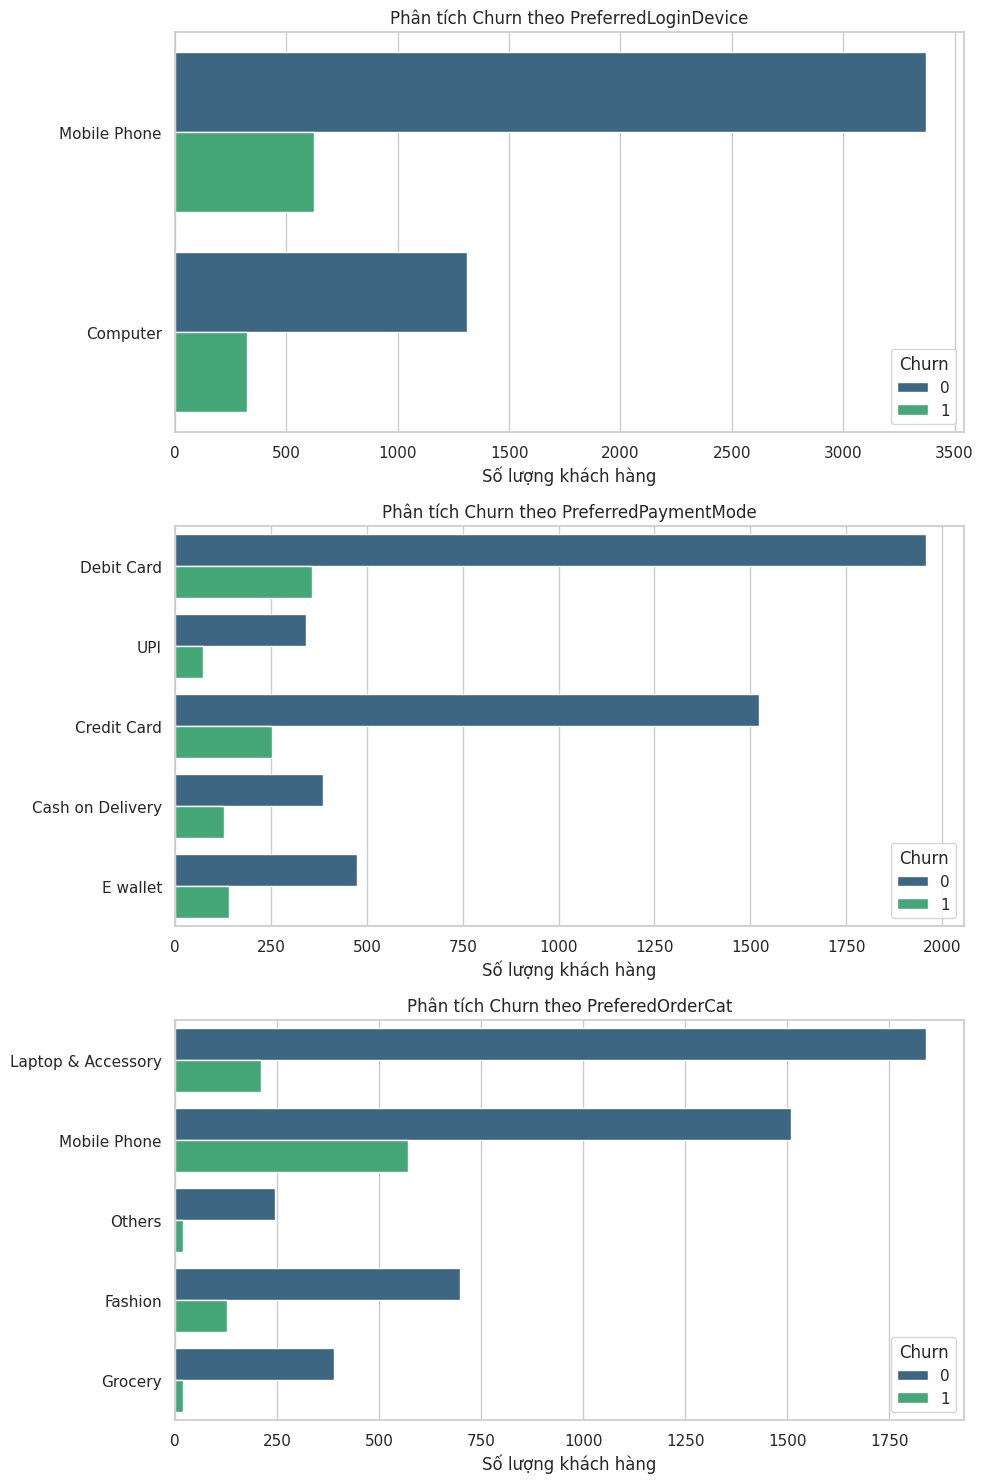


--- Tỷ lệ Churn theo nhóm Thời gian gắn bó ---


/tmp/ipykernel_2007/2632014097.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate_by_tenure = df.groupby('Tenure_Group')['Churn'].mean().reset_index()
/tmp/ipykernel_2007/2632014097.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tenure_Group', y='Churn', data=churn_rate_by_tenure, palette='coolwarm')


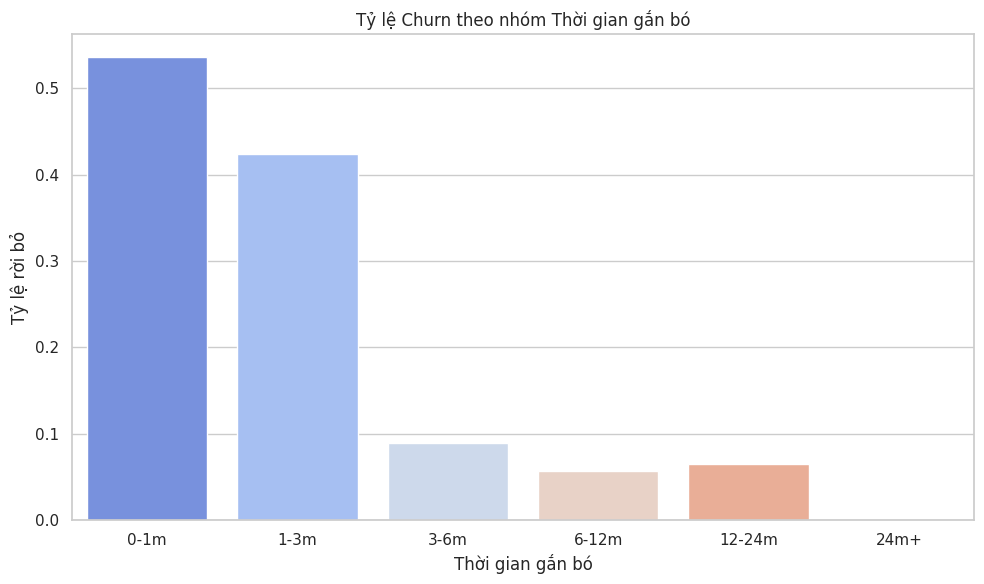


--- Tỷ lệ Churn theo Mức độ hài lòng ---


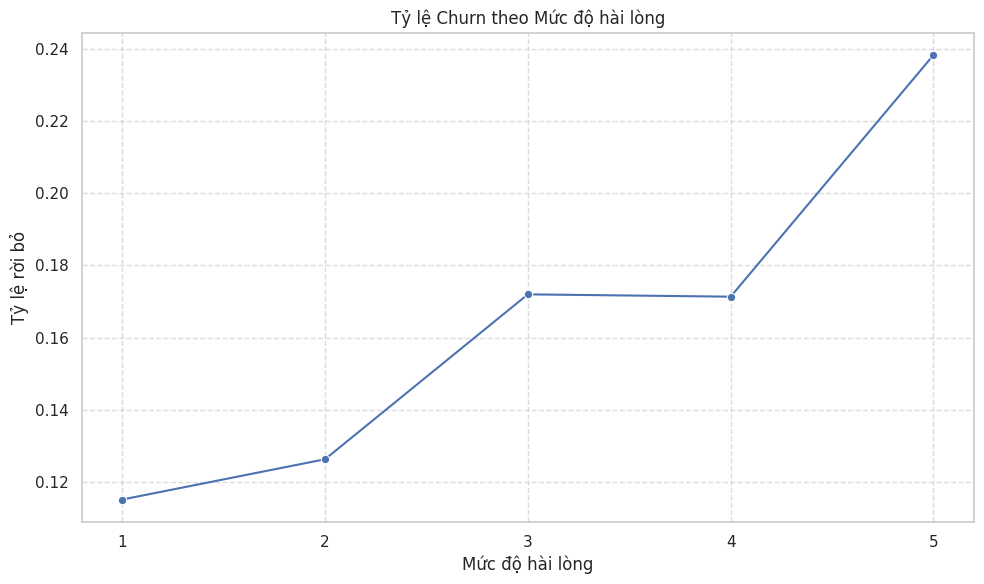

In [ ]:
df_cleaned = clean_data('/content/drive/MyDrive/Colab Notebooks/data/E_Comm_Cleaned_median.csv')

exploratory_data_analysis(df_cleaned)

--- Đang tải dữ liệu ---

Giá trị trung vị của các cột có dữ liệu thiếu:
WarehouseToHome: 14.0
HourSpendOnApp: 3.0

--- Làm sạch hoàn tất ---

5 dòng dữ liệu đầu tiên sau khi xử lý:
   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN         Mobile Phone         1              8.0   
2       50003      1     NaN         Mobile Phone         1             30.0   
3       50004      1     0.0         Mobile Phone         3             15.0   
4       50005      1     0.0         Mobile Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  \
0           Debit Card  Female             3.0                         3   
1                  UPI    Male             3.0                         4   
2           Debit Card    Male             2.0                         4   
3           Debit Card    Male   

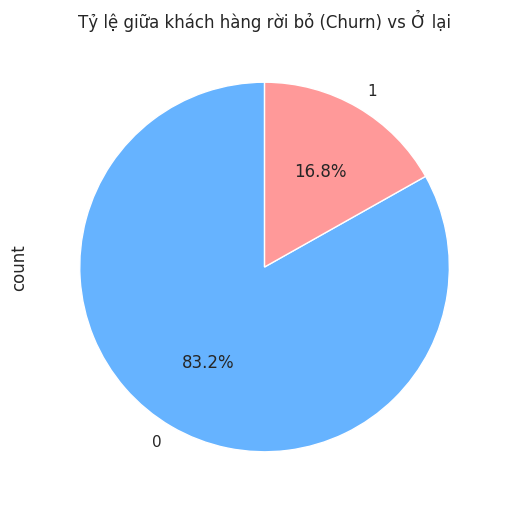

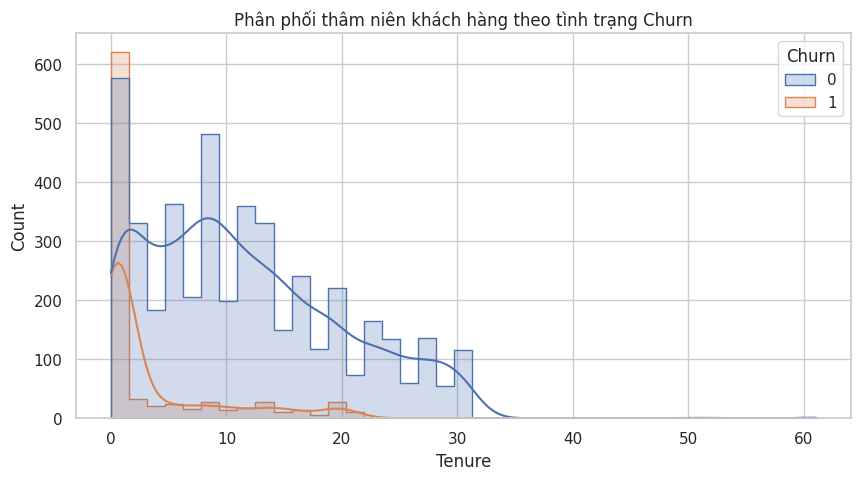

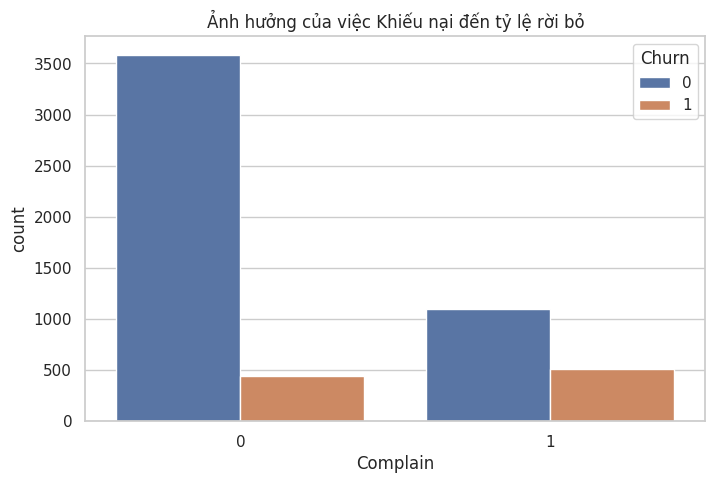

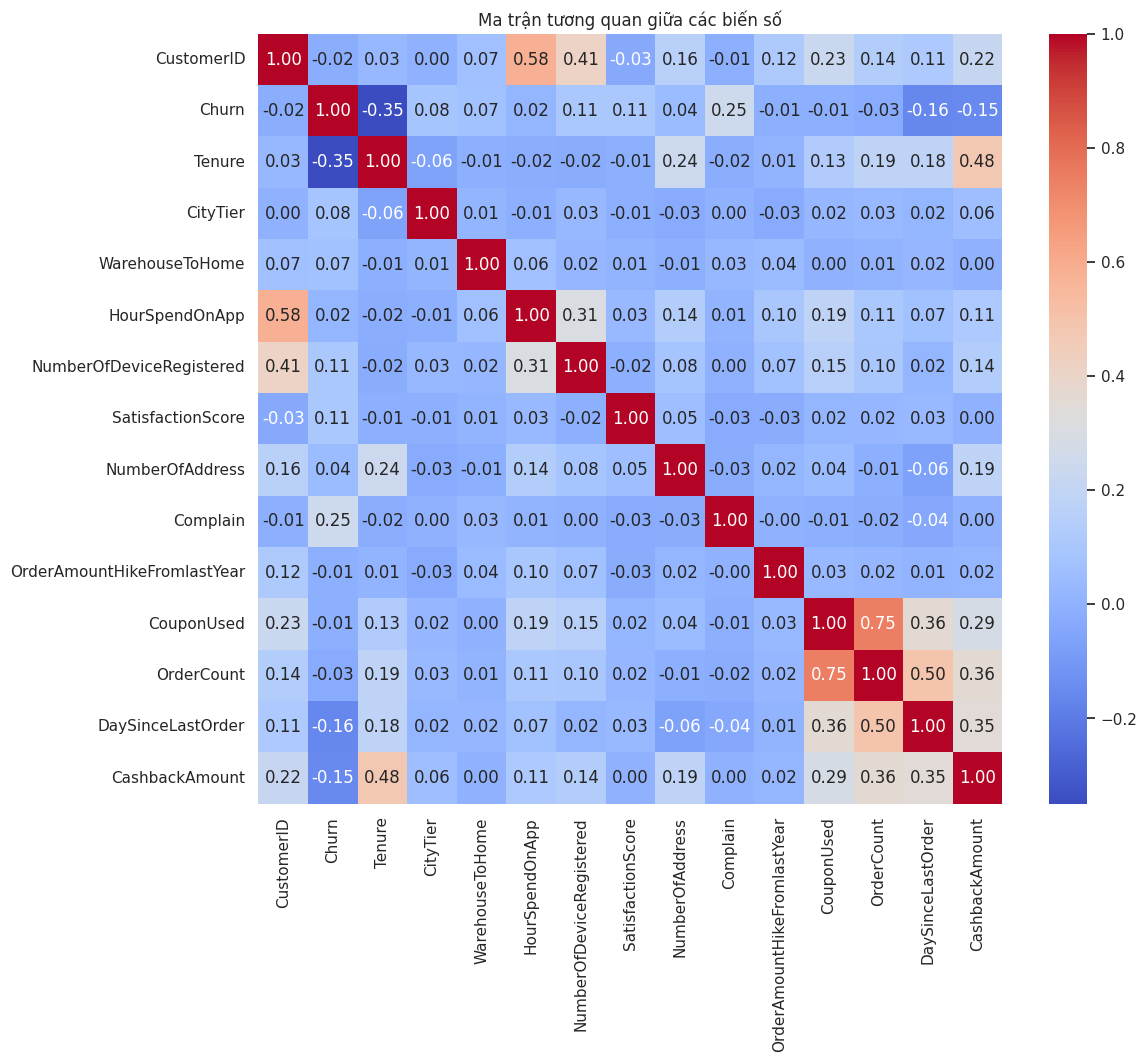


--- Phân tích tỷ lệ rời bỏ theo các đặc trưng phân loại ---


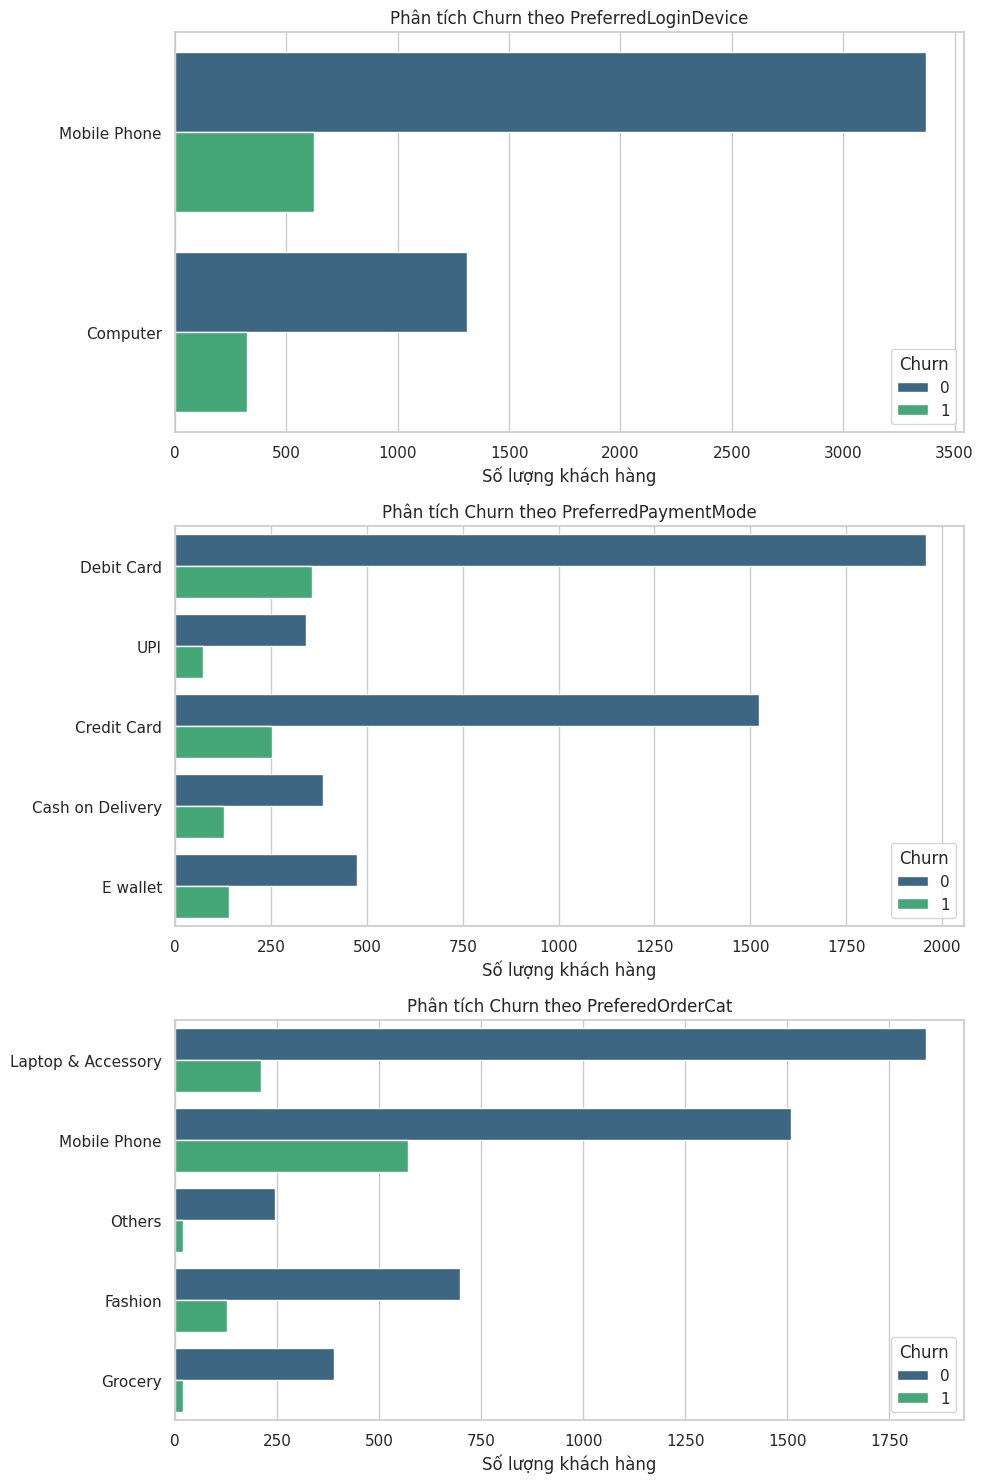


--- Tỷ lệ Churn theo nhóm Thời gian gắn bó ---


/tmp/ipykernel_2007/2632014097.py:57: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rate_by_tenure = df.groupby('Tenure_Group')['Churn'].mean().reset_index()
/tmp/ipykernel_2007/2632014097.py:60: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Tenure_Group', y='Churn', data=churn_rate_by_tenure, palette='coolwarm')


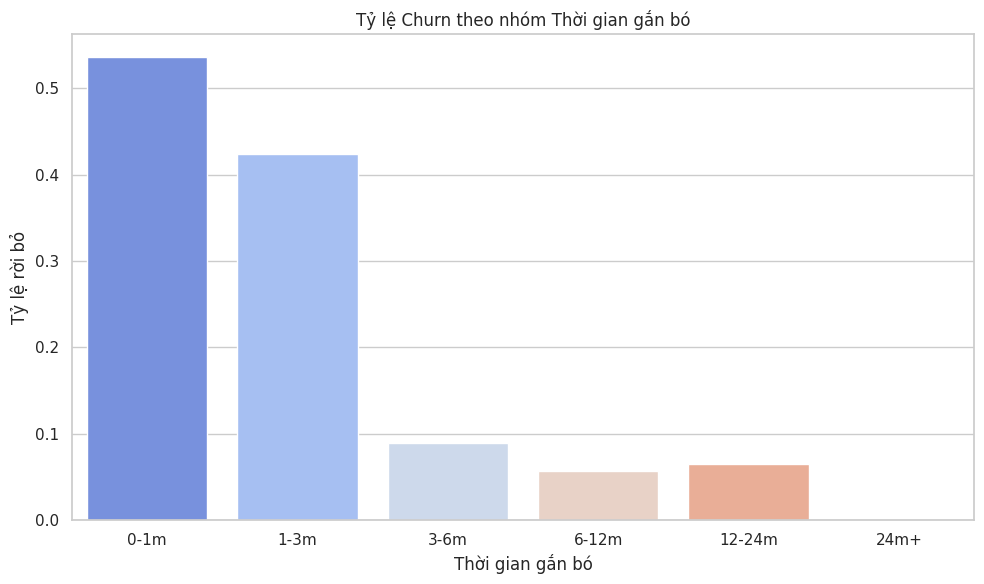


--- Tỷ lệ Churn theo Mức độ hài lòng ---


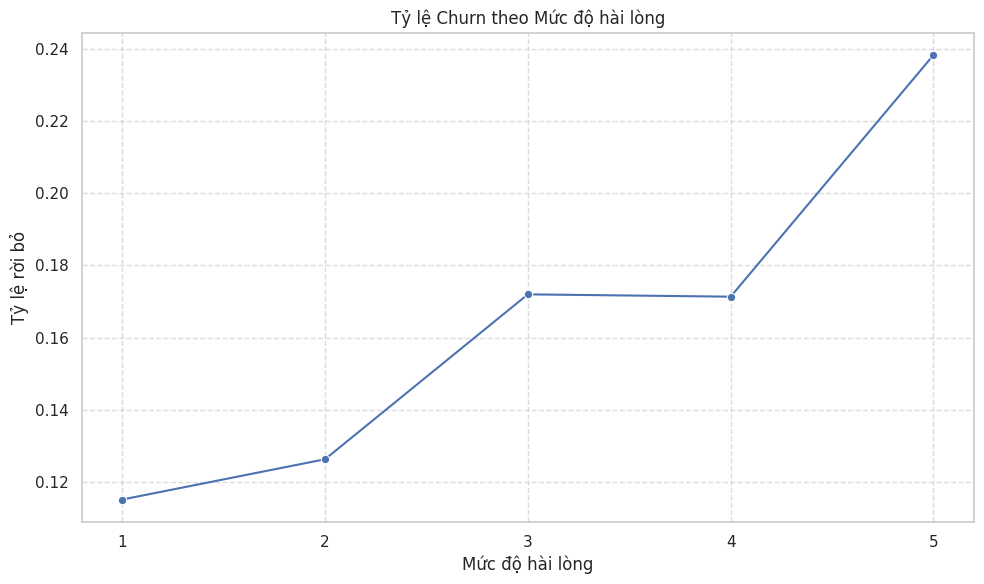


Đã lưu file làm sạch thành công: E_Comm_Cleaned.csv


In [ ]:
if __name__ == "__main__":
    # Thay đổi đường dẫn này nếu bạn đặt tên file khác khi upload lên Colab
    FILE_PATH = '/content/drive/MyDrive/Colab Notebooks/data/E Commerce Dataset.csv'

    try:
        # Thực thi quy trình
        cleaned_df = clean_data(FILE_PATH)

        # Xem 5 dòng đầu tiên sau khi làm sạch
        print("\n5 dòng dữ liệu đầu tiên sau khi xử lý:")
        print(cleaned_df.head())

        # Phân tích
        exploratory_data_analysis(cleaned_df)

        # Lưu file đã làm sạch
        cleaned_df.to_csv('E_Comm_Cleaned.csv', index=False)
        print("\nĐã lưu file làm sạch thành công: E_Comm_Cleaned.csv")

    except FileNotFoundError:
        print(f"Lỗi: Không tìm thấy file tại '{FILE_PATH}'. Vui lòng tải file lên Colab trước.")

##Phân lớp khách hàng(RFM)



In [ ]:
import sqlite3
import pandas as pd

# Khởi tạo in-memory database
conn = sqlite3.connect(":memory:")

# Đẩy dữ liệu đã làm sạch vào database với tên bảng 'ecommerce_data'
# Đảm bảo sử dụng DataFrame đã được làm sạch (cleaned_df)
cleaned_df.to_sql('ecommerce_data', conn, if_exists='replace', index=False)

# 1. Tính toán điểm R, F, M sử dụng NTILE(5)
# R (Recency): DaySinceLastOrder (số ngày nghỉ mua càng THẤP thì điểm R càng CAO) -> ORDER BY DESC
# F (Frequency): OrderCount (mua càng nhiều thì điểm F càng CAO) -> ORDER BY ASC
# M (Monetary): CashbackAmount (hoàn tiền càng nhiều thì điểm M càng CAO) -> ORDER BY ASC
rfm_query = """
WITH RFM_Scores AS (
    SELECT
        CustomerID,
        NTILE(5) OVER (ORDER BY DaySinceLastOrder DESC) AS R_Score,
        NTILE(5) OVER (ORDER BY OrderCount ASC) AS F_Score,
        NTILE(5) OVER (ORDER BY CashbackAmount ASC) AS M_Score
    FROM
        ecommerce_data
)
SELECT
    *,
    CASE
        WHEN R_Score >= 4 AND F_Score >= 4 AND M_Score >= 4 THEN 'Champions' -- Rất tốt, thường xuyên mua, chi tiêu cao
        WHEN R_Score >= 3 AND F_Score >= 3 AND M_Score >= 3 THEN 'Loyal Customers' -- Trung thành, mua thường xuyên, chi tiêu ổn định
        WHEN R_Score >= 4 AND (F_Score >= 2 OR M_Score >= 2) THEN 'Potential Loyalists' -- Mới mua gần đây, có tiềm năng thành khách trung thành
        WHEN R_Score >= 4 AND F_Score <= 1 AND M_Score <= 1 THEN 'New Customers' -- Khách hàng mới, chỉ mua 1 lần

        WHEN R_Score = 3 AND F_Score <= 2 THEN 'About to Sleep' -- Khách hàng đã lâu không mua, nếu không tác động sẽ mất.
        WHEN R_Score = 3 AND (F_Score > 2 OR M_Score > 2) THEN 'Need Attention' -- Khách hàng có giá trị nhưng đang có dấu hiệu chững lại.
        WHEN R_Score <= 2 AND (F_Score = 5 OR M_Score = 5) THEN 'Cant Lose Them' -- Từng là khách hàng cực VIP nhưng đã ngưng mua hẳn.

        WHEN R_Score <= 2 AND (F_Score >= 2 OR M_Score >= 2) THEN 'At Risk' -- Lâu rồi không mua, nhưng từng có hoạt động
        WHEN R_Score <= 2 AND F_Score <= 2 AND M_Score <= 2 THEN 'Lost' -- Rất lâu rồi không mua, hoạt động thấp
        ELSE 'Others' -- Các khách hàng còn lại không thuộc nhóm trên
    END AS RFM_Segment
FROM
    RFM_Scores;
"""

# Chạy truy vấn và lưu kết quả vào DataFrame mới
rfm_df = pd.read_sql_query(rfm_query, conn)

# Hợp nhất cột 'Churn' từ cleaned_df vào rfm_df
# Lưu ý: 'CustomerID' là cột chung để hợp nhất
rfm_df = pd.merge(rfm_df, cleaned_df[['CustomerID', 'Churn']], on='CustomerID', how='left')

print("\n--- Phân tích RFM hoàn tất ---")
print("5 dòng đầu tiên của dữ liệu RFM:\n")
print(rfm_df.head())

print("\nPhân phối khách hàng theo các phân khúc RFM:\n")
print(rfm_df['RFM_Segment'].value_counts())

# Đóng kết nối database
conn.close()



--- Phân tích RFM hoàn tất ---
5 dòng đầu tiên của dữ liệu RFM:

   CustomerID  R_Score  F_Score  M_Score     RFM_Segment  Churn
0       52041        1        5        4  Cant Lose Them      1
1       54306        1        4        3         At Risk      0
2       51491        1        2        1         At Risk      0
3       53566        1        3        3         At Risk      0
4       53377        1        4        3         At Risk      0

Phân phối khách hàng theo các phân khúc RFM:

RFM_Segment
Cant Lose Them         1147
Potential Loyalists     999
At Risk                 950
Loyal Customers         816
New Customers           549
Champions               490
Need Attention          277
About to Sleep          247
Lost                    155
Name: count, dtype: int64



--- Tỷ lệ Churn theo các phân khúc RFM ---
           RFM_Segment     Churn
0        New Customers  0.335155
1  Potential Loyalists  0.225225
2       Need Attention  0.180505
3            Champions  0.167347
4      Loyal Customers  0.148284
5       About to Sleep  0.145749
6                 Lost  0.141935
7       Cant Lose Them  0.120314
8              At Risk  0.094737


/tmp/ipykernel_2007/1106710117.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='RFM_Segment', y='Churn', data=churn_rate_by_rfm, palette='coolwarm')


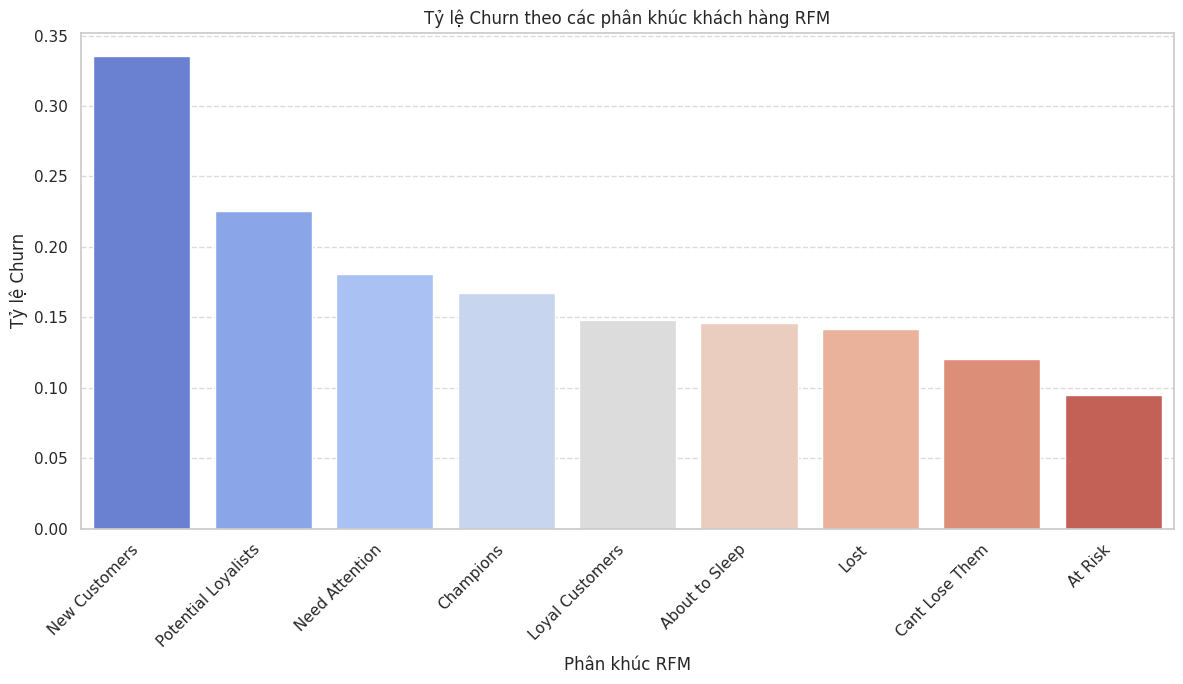

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Tính toán tỷ lệ Churn cho từng phân khúc RFM
churn_rate_by_rfm = rfm_df.groupby('RFM_Segment')['Churn'].mean().sort_values(ascending=False).reset_index()

print("\n--- Tỷ lệ Churn theo các phân khúc RFM ---")
print(churn_rate_by_rfm)

# Vẽ biểu đồ tỷ lệ Churn cho từng phân khúc RFM
plt.figure(figsize=(12, 7))
sns.barplot(x='RFM_Segment', y='Churn', data=churn_rate_by_rfm, palette='coolwarm')
plt.title('Tỷ lệ Churn theo các phân khúc khách hàng RFM')
plt.xlabel('Phân khúc RFM')
plt.ylabel('Tỷ lệ Churn')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# Tính toán tổng điểm RFM
rfm_df['rfm_total'] = rfm_df['R_Score'] + rfm_df['F_Score'] + rfm_df['M_Score']

# Hợp nhất tổng điểm RFM và phân khúc RFM vào DataFrame gốc đã làm sạch
# Sử dụng CustomerID làm khóa chính để hợp nhất
cleaned_df_with_rfm = pd.merge(cleaned_df, rfm_df[['CustomerID', 'rfm_total', 'RFM_Segment']], on='CustomerID', how='left')

print("--- Đã thêm điểm và phân khúc RFM vào dữ liệu gốc ---")
print("5 dòng đầu tiên của DataFrame sau khi hợp nhất RFM:\n")
print(cleaned_df_with_rfm.head())

print("\nThông tin các cột RFM mới được thêm:\n")
print(cleaned_df_with_rfm[['CustomerID', 'rfm_total', 'RFM_Segment', 'Churn']].head())

# Lưu DataFrame đã làm sạch và bổ sung RFM vào một file CSV mới
output_file_path = '/content/drive/MyDrive/Colab Notebooks/data/E_Comm_Cleaned_with_RFM.csv'
cleaned_df_with_rfm.to_csv(output_file_path, index=False)
print(f"\nDataFrame đã được lưu thành công vào: {output_file_path}")

--- Đã thêm điểm và phân khúc RFM vào dữ liệu gốc ---
5 dòng đầu tiên của DataFrame sau khi hợp nhất RFM:

   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN         Mobile Phone         1              8.0   
2       50003      1     NaN         Mobile Phone         1             30.0   
3       50004      1     0.0         Mobile Phone         3             15.0   
4       50005      1     0.0         Mobile Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  ...  \
0           Debit Card  Female             3.0                         3  ...   
1                  UPI    Male             3.0                         4  ...   
2           Debit Card    Male             2.0                         4  ...   
3           Debit Card    Male             2.0                         4  ...   
4      

##Preprocessing

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/E_Comm_Cleaned_with_RFM.csv')
print(df.head(5))

   CustomerID  Churn  Tenure PreferredLoginDevice  CityTier  WarehouseToHome  \
0       50001      1     4.0         Mobile Phone         3              6.0   
1       50002      1     NaN         Mobile Phone         1              8.0   
2       50003      1     NaN         Mobile Phone         1             30.0   
3       50004      1     0.0         Mobile Phone         3             15.0   
4       50005      1     0.0         Mobile Phone         1             12.0   

  PreferredPaymentMode  Gender  HourSpendOnApp  NumberOfDeviceRegistered  ...  \
0           Debit Card  Female             3.0                         3  ...   
1                  UPI    Male             3.0                         4  ...   
2           Debit Card    Male             2.0                         4  ...   
3           Debit Card    Male             2.0                         4  ...   
4          Credit Card    Male             3.0                         3  ...   

  NumberOfAddress  Complain Orde

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import KNNImputer

# 0. Load dữ liệu đã được làm sạch và bổ sung RFM
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/E_Comm_Cleaned_with_RFM.csv')

# 1. Chia dữ liệu TRƯỚC (Dữ liệu thô, chưa encode)
X = df.drop(columns=['Churn'])
y = df['Churn'].astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# 2. Xử lý One-Hot Encoding cho các cột phân loại
# Xác định các cột chữ cần encode (không bao gồm CustomerID và Tenure_Group nếu không muốn encode)
# CustomerID không phải là feature, Tenure_Group là cột tạm thời từ EDA, có thể bỏ
cat_cols = X_train.select_dtypes(include=['object','category']).columns.tolist()

# Khởi tạo Encoder
# handle_unknown='ignore' giúp model không bị crash khi gặp giá trị lạ ở tập Test
# drop='first' giúp tránh bẫy biến giả (dummy variable trap)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False, drop='first')

# Học từ Train và áp dụng lên cả Train và Test
X_train_enc = encoder.fit_transform(X_train[cat_cols])
X_test_enc  = encoder.transform(X_test[cat_cols])

# Tạo DataFrame cho các cột đã được encode
X_train_enc_df = pd.DataFrame(X_train_enc, columns=encoder.get_feature_names_out(cat_cols), index=X_train.index)
X_test_enc_df = pd.DataFrame(X_test_enc, columns=encoder.get_feature_names_out(cat_cols), index=X_test.index)

# Bỏ các cột phân loại gốc và nối các cột đã được encode vào
X_train = X_train.drop(columns=cat_cols).merge(X_train_enc_df, left_index=True, right_index=True)
X_test = X_test.drop(columns=cat_cols).merge(X_test_enc_df, left_index=True, right_index=True)

# 3. Scaling & KNN Impute — fit ONLY on train
# Xác định các cột số để xử lý (loại bỏ CustomerID nếu nó vẫn còn và không muốn đưa vào model)
num_cols_imp = X_train.select_dtypes(include=[np.number]).columns.tolist()

# 1. Bắt buộc Scaling trước khi KNN Imputer
scaler = MinMaxScaler()
X_train[num_cols_imp] = scaler.fit_transform(X_train[num_cols_imp])
X_test[num_cols_imp]  = scaler.transform(X_test[num_cols_imp])

# 2. Bây giờ KNN Imputer mới hoạt động chính xác
imputer = KNNImputer(n_neighbors=5)
X_train[num_cols_imp] = imputer.fit_transform(X_train[num_cols_imp])
X_test[num_cols_imp]  = imputer.transform(X_test[num_cols_imp])

print("Preprocessing hoàn tất. Dữ liệu đã sẵn sàng cho huấn luyện mô hình.")
print(f"Kích thước X_train sau preprocessing: {X_train.shape}")
print(f"Kích thước X_test sau preprocessing: {X_test.shape}")

Preprocessing hoàn tất. Dữ liệu đã sẵn sàng cho huấn luyện mô hình.
Kích thước X_train sau preprocessing: (4504, 41)
Kích thước X_test sau preprocessing: (1126, 41)


In [ ]:
from imblearn.over_sampling import SMOTE
import pandas as pd

# ── SMOTE — bây giờ sẽ chạy mượt ──
print(f"\nBefore SMOTE: {y_train.value_counts().to_dict()}")

# Dùng dữ liệu đã encoded (X_train) thay vì X_train gốc
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f"After SMOTE: {y_train_res.value_counts().to_dict()}")
print(f"Kích thước X_train_res sau SMOTE: {X_train_res.shape}")


Before SMOTE: {0: 3746, 1: 758}
After SMOTE: {0: 3746, 1: 3746}
Kích thước X_train_res sau SMOTE: (7492, 41)



--- Kiểm tra giá trị NaN sau preprocessing và SMOTE ---
NaN trong X_train_res: False
NaN trong X_test: False
Không có giá trị NaN nào được tìm thấy. Dữ liệu đã sẵn sàng để huấn luyện mô hình.

--- Huấn luyện mô hình Logistic Regression ---
Mô hình Logistic Regression đã được huấn luyện thành công.

--- Đánh giá mô hình ---
Báo cáo phân loại trên tập kiểm thử:
              precision    recall  f1-score   support

           0       0.96      0.85      0.90       936
           1       0.53      0.81      0.64       190

    accuracy                           0.84      1126
   macro avg       0.74      0.83      0.77      1126
weighted avg       0.88      0.84      0.86      1126

Ma trận nhầm lẫn:
[[797 139]
 [ 36 154]]
Độ chính xác của mô hình: 0.8446
ROC AUC: 0.9015
PR AUC: 0.7120


/tmp/ipykernel_2007/2887685359.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=f1_scores, palette='viridis')


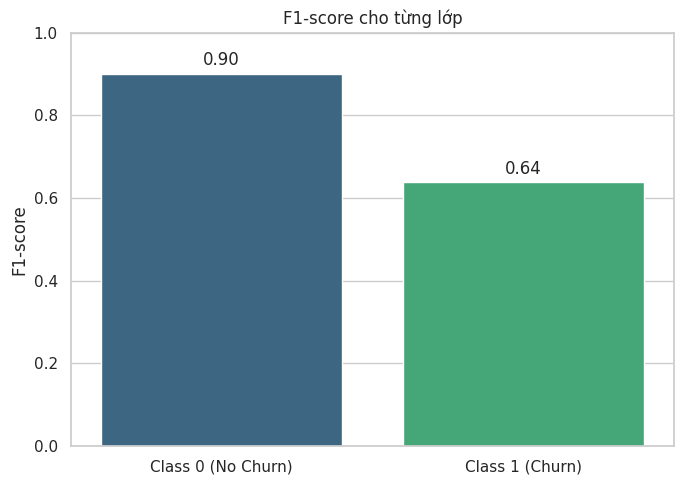


--- Phân tích Feature Importances từ mô hình Logistic Regression ---
Các đặc trưng quan trọng nhất (dựa trên giá trị tuyệt đối của hệ số):
                 Feature  Coefficient  Abs_Coefficient
                  Tenure    -5.128024         5.128024
       Tenure_Group_24m+    -4.957341         4.957341
         NumberOfAddress     4.723571         4.723571
         WarehouseToHome     3.630041         3.630041
          CashbackAmount    -3.299890         3.299890
       Tenure_Group_3-6m    -2.926672         2.926672
      Tenure_Group_6-12m    -2.780097         2.780097
     Tenure_Group_12-24m    -2.292486         2.292486
NumberOfDeviceRegistered     2.222259         2.222259
       DaySinceLastOrder    -2.192324         2.192324


/tmp/ipykernel_2007/2887685359.py:92: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Abs_Coefficient', y='Feature', data=importance_df_lr.head(10), palette='viridis')


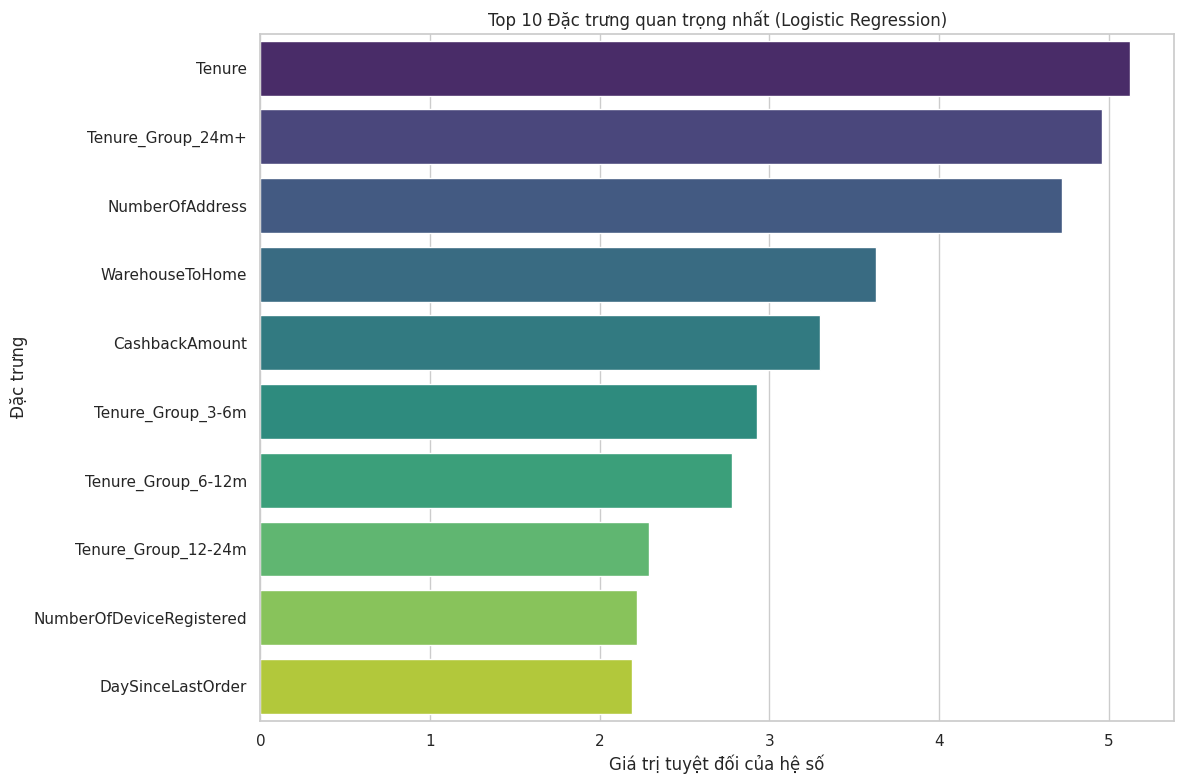

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, roc_auc_score, precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

print("\n--- Kiểm tra giá trị NaN sau preprocessing và SMOTE ---")
print(f"NaN trong X_train_res: {np.any(np.isnan(X_train_res))}")
print(f"NaN trong X_test: {np.any(np.isnan(X_test))}")

if np.any(np.isnan(X_train_res)) or np.any(np.isnan(X_test)):
    print("Cảnh báo: Vẫn còn giá trị NaN sau tiền xử lý. Vui lòng kiểm tra lại bước xử lý NaN.")
else:
    print("Không có giá trị NaN nào được tìm thấy. Dữ liệu đã sẵn sàng để huấn luyện mô hình.")

print("\n--- Huấn luyện mô hình Logistic Regression ---")
# Khởi tạo mô hình Logistic Regression
# max_iter tăng lên để đảm bảo hội tụ, class_weight='balanced' nếu không dùng SMOTE
model = LogisticRegression(random_state=42, solver='liblinear', max_iter=200)

# Huấn luyện mô hình trên dữ liệu đã được SMOTE
model.fit(X_train_res, y_train_res)

print("Mô hình Logistic Regression đã được huấn luyện thành công.")

print("\n--- Đánh giá mô hình ---")
# Dự đoán trên tập kiểm thử
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1] # Xác suất cho lớp dương (Churn)

# In báo cáo phân loại
print("Báo cáo phân loại trên tập kiểm thử:")
report = classification_report(y_test, y_pred, output_dict=True)
print(classification_report(y_test, y_pred))

# In ma trận nhầm lẫn
print("Ma trận nhầm lẫn:")
print(confusion_matrix(y_test, y_pred))

# In độ chính xác
accuracy = accuracy_score(y_test, y_pred)
print(f"Độ chính xác của mô hình: {accuracy:.4f}")

# Tính toán và in ROC AUC
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC: {roc_auc:.4f}")

# Tính toán và in PR AUC
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
pr_auc = auc(recall, precision)
print(f"PR AUC: {pr_auc:.4f}")

# Biểu đồ F1-score
f1_scores = [report['0']['f1-score'], report['1']['f1-score']]
labels = ['Class 0 (No Churn)', 'Class 1 (Churn)']

plt.figure(figsize=(7, 5))
sns.barplot(x=labels, y=f1_scores, palette='viridis')
plt.title('F1-score cho từng lớp')
plt.ylabel('F1-score')
plt.ylim(0, 1)
for index, value in enumerate(f1_scores):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')
plt.tight_layout()
plt.show()

# --- Phân tích Feature Importances từ mô hình Logistic Regression ---
print("\n--- Phân tích Feature Importances từ mô hình Logistic Regression ---")

# Lấy các hệ số (coefficients) từ mô hình Logistic Regression
coefficients = model.coef_[0]

# Lấy tên các cột từ X_train_res
features = X_train_res.columns

# Tạo DataFrame để dễ dàng sắp xếp và trực quan hóa
importance_df_lr = pd.DataFrame({'Feature': features, 'Coefficient': coefficients})

# Tính giá trị tuyệt đối của hệ số để đánh giá độ lớn ảnh hưởng
importance_df_lr['Abs_Coefficient'] = np.abs(importance_df_lr['Coefficient'])

# Sắp xếp theo giá trị tuyệt đối của hệ số giảm dần
importance_df_lr = importance_df_lr.sort_values(by='Abs_Coefficient', ascending=False)

# In ra các đặc trưng quan trọng nhất (ví dụ: top 10)
print("Các đặc trưng quan trọng nhất (dựa trên giá trị tuyệt đối của hệ số):")
print(importance_df_lr.head(10).to_string(index=False))

# Vẽ biểu đồ các đặc trưng quan trọng nhất
plt.figure(figsize=(12, 8))
sns.barplot(x='Abs_Coefficient', y='Feature', data=importance_df_lr.head(10), palette='viridis')
plt.title('Top 10 Đặc trưng quan trọng nhất (Logistic Regression)')
plt.xlabel('Giá trị tuyệt đối của hệ số')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()


--- Huấn luyện mô hình Random Forest ---
Mô hình Random Forest đã được huấn luyện thành công.

--- Đánh giá mô hình Random Forest ---
Báo cáo phân loại trên tập kiểm thử (Random Forest):
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       936
           1       0.88      0.88      0.88       190

    accuracy                           0.96      1126
   macro avg       0.93      0.93      0.93      1126
weighted avg       0.96      0.96      0.96      1126

Ma trận nhầm lẫn (Random Forest):
[[914  22]
 [ 23 167]]


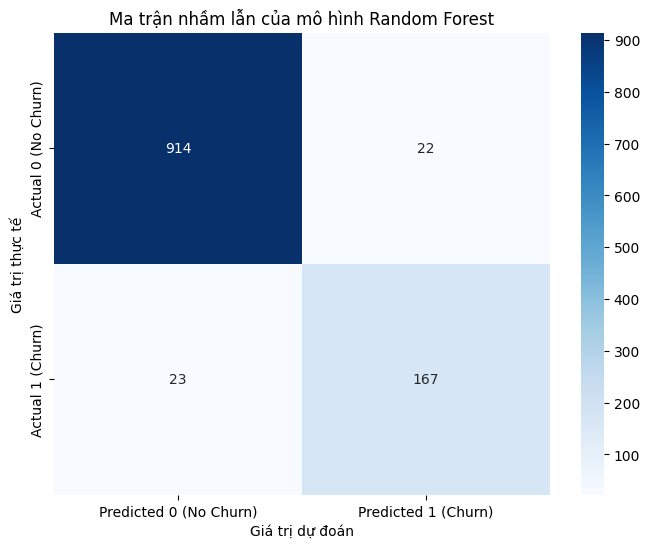

Độ chính xác của mô hình Random Forest: 0.9600
ROC AUC (Random Forest): 0.9928
PR AUC (Random Forest): 0.9659


/tmp/ipykernel_7701/3862183877.py:61: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=f1_scores_rf, palette='viridis')


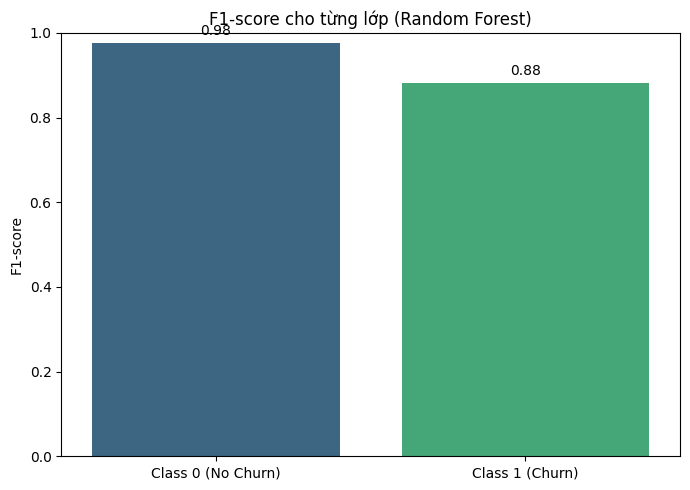


--- Trực quan hóa một cây quyết định trong Random Forest ---


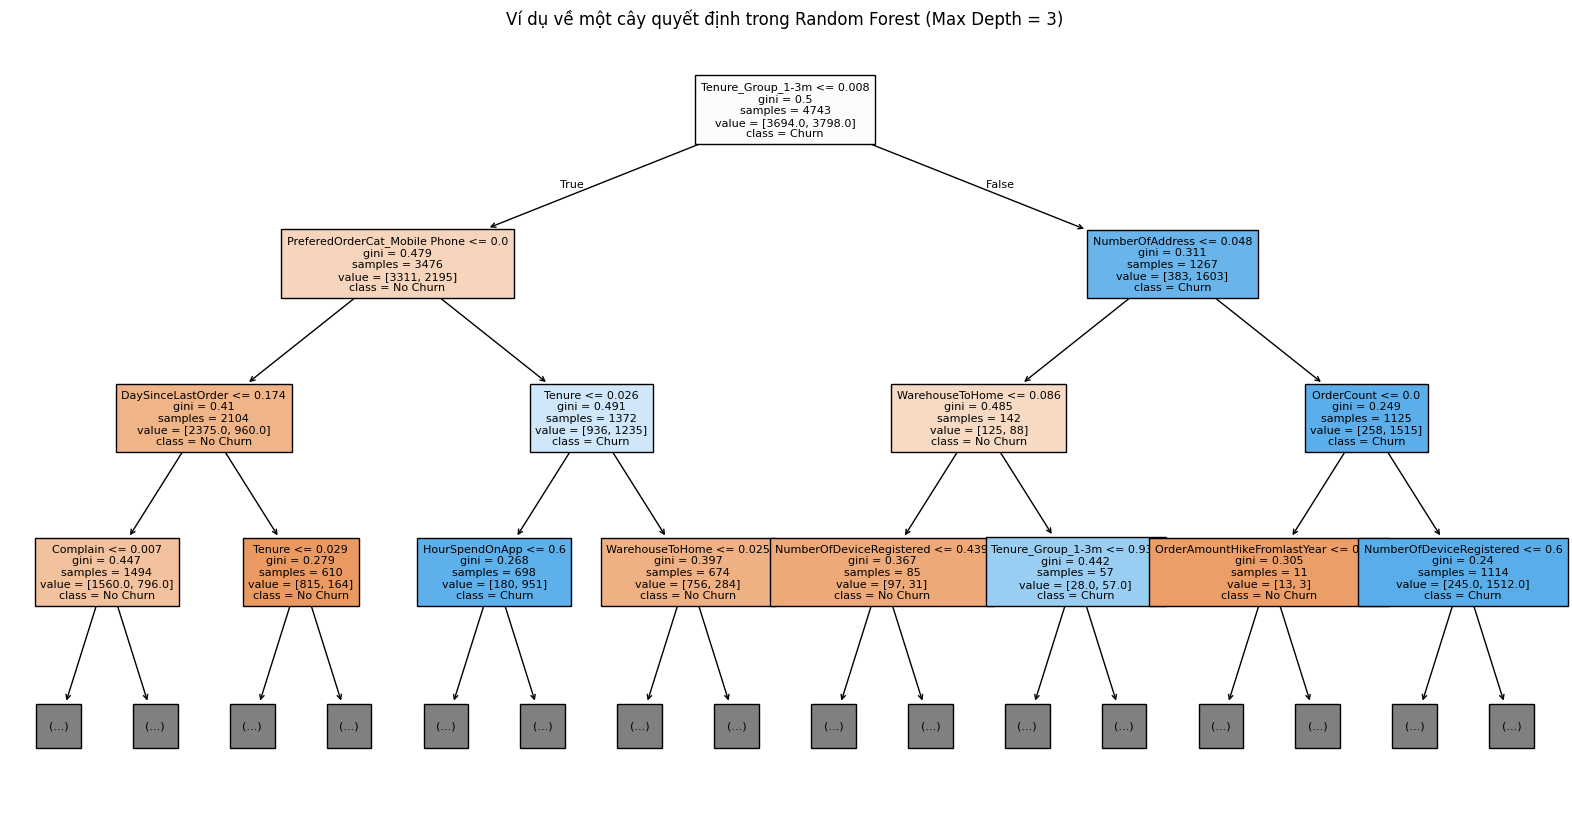

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, roc_auc_score, precision_recall_curve, auc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# --- Huấn luyện mô hình Random Forest ---
print("\n--- Huấn luyện mô hình Random Forest ---")
# Khởi tạo mô hình Random Forest
rf_model = RandomForestClassifier(random_state=42, n_estimators=100, class_weight='balanced')

# Huấn luyện mô hình trên dữ liệu đã được SMOTE
rf_model.fit(X_train_res, y_train_res)

print("Mô hình Random Forest đã được huấn luyện thành công.")

print("\n--- Đánh giá mô hình Random Forest ---")
# Dự đoán trên tập kiểm thử
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1] # Xác suất cho lớp dương (Churn)

# In báo cáo phân loại
print("Báo cáo phân loại trên tập kiểm thử (Random Forest):")
report_rf = classification_report(y_test, y_pred_rf, output_dict=True)
print(classification_report(y_test, y_pred_rf))

# In ma trận nhầm lẫn
print("Ma trận nhầm lẫn (Random Forest):")
cm_rf = confusion_matrix(y_test, y_pred_rf)
print(cm_rf)

# Vẽ biểu đồ heatmap cho ma trận nhầm lẫn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (No Churn)', 'Predicted 1 (Churn)'],
            yticklabels=['Actual 0 (No Churn)', 'Actual 1 (Churn)'])
plt.title('Ma trận nhầm lẫn của mô hình Random Forest')
plt.ylabel('Giá trị thực tế')
plt.xlabel('Giá trị dự đoán')
plt.show()

# In độ chính xác
accuracy_rf = accuracy_score(y_test, y_pred_rf)
print(f"Độ chính xác của mô hình Random Forest: {accuracy_rf:.4f}")

# Tính toán và in ROC AUC
roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"ROC AUC (Random Forest): {roc_auc_rf:.4f}")

# Tính toán và in PR AUC
precision_rf, recall_rf, _ = precision_recall_curve(y_test, y_pred_proba_rf)
pr_auc_rf = auc(recall_rf, precision_rf)
print(f"PR AUC (Random Forest): {pr_auc_rf:.4f}")

# Biểu đồ F1-score
f1_scores_rf = [report_rf['0']['f1-score'], report_rf['1']['f1-score']]
labels = ['Class 0 (No Churn)', 'Class 1 (Churn)']

plt.figure(figsize=(7, 5))
sns.barplot(x=labels, y=f1_scores_rf, palette='viridis')
plt.title('F1-score cho từng lớp (Random Forest)')
plt.ylabel('F1-score')
plt.ylim(0, 1)
for index, value in enumerate(f1_scores_rf):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')
plt.tight_layout()
plt.show()

# --- Trực quan hóa một cây trong Random Forest ---
print("\n--- Trực quan hóa một cây quyết định trong Random Forest ---")
# Lấy ra cây đầu tiên từ Random Forest để trực quan hóa
one_tree = rf_model.estimators_[0]

plt.figure(figsize=(20, 10))
plot_tree(one_tree,
          feature_names=X_train_res.columns.tolist(),
          class_names=['No Churn', 'Churn'],
          filled=True,
          max_depth=3, # Chỉ hiển thị một vài tầng đầu tiên để dễ nhìn
          fontsize=8)
plt.title('Ví dụ về một cây quyết định trong Random Forest (Max Depth = 3)')
# Chú thích: Trong mỗi node, 'class' chỉ ra lớp chiếm đa số của các mẫu thuộc node đó.
# Để đưa ra dự đoán cuối cùng cho một mẫu, bạn phải đi theo các điều kiện từ node gốc
# cho đến khi đạt đến một node lá (leaf node), nơi quyết định cuối cùng được đưa ra.
# Biểu đồ này thể hiện rõ logic 'nếu điều kiện này đúng thì tiếp tục kiểm tra ở nhánh trái,
# ngược lại kiểm tra ở nhánh phải'.
plt.show()


--- Phân tích Feature Importances từ mô hình Random Forest ---
Các đặc trưng quan trọng nhất:
                        Feature  Importance
1                        Tenure    0.171943
8                      Complain    0.068633
7               NumberOfAddress    0.046975
13               CashbackAmount    0.046495
12            DaySinceLastOrder    0.045379
27            Tenure_Group_1-3m    0.044620
6             SatisfactionScore    0.042425
3               WarehouseToHome    0.041544
5      NumberOfDeviceRegistered    0.039743
9   OrderAmountHikeFromlastYear    0.034333


/tmp/ipykernel_2007/3461833954.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')


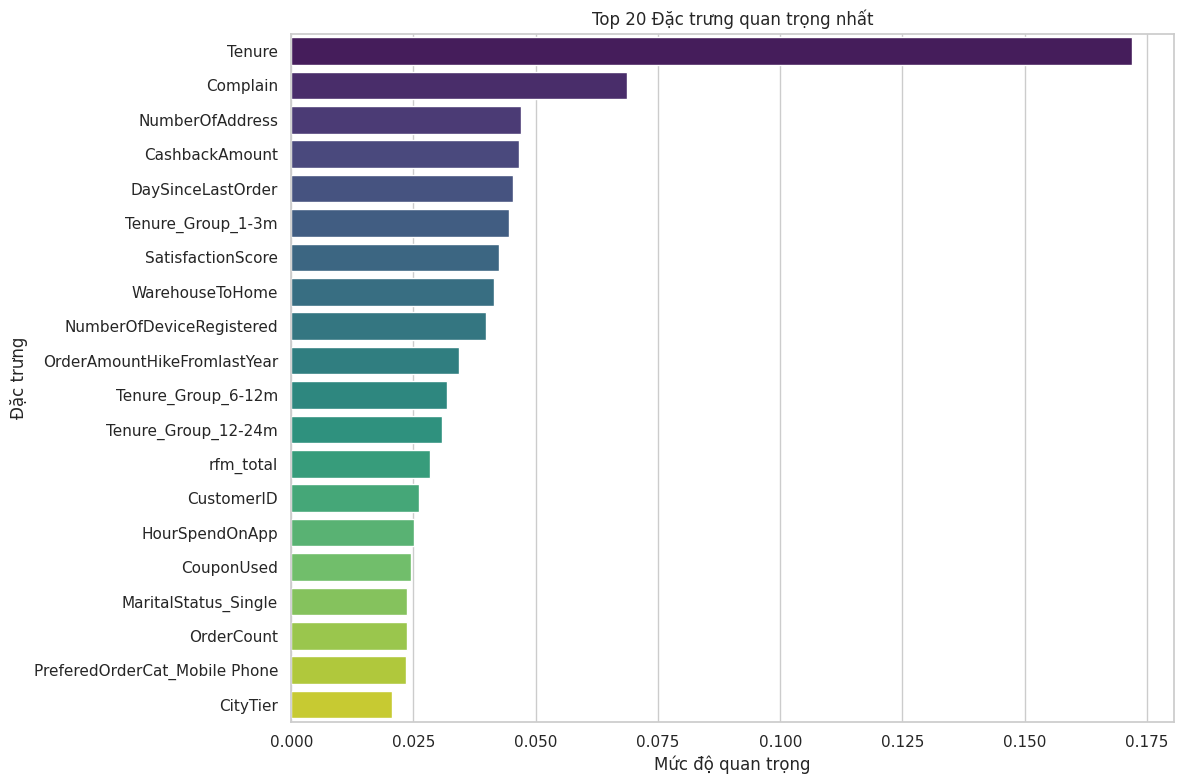

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("\n--- Phân tích Feature Importances từ mô hình Random Forest ---")

# Lấy các feature importances
feature_importances = rf_model.feature_importances_

# Lấy tên các cột từ X_train_res
features = X_train_res.columns

# Tạo DataFrame để dễ dàng sắp xếp và trực quan hóa
importance_df = pd.DataFrame({'Feature': features, 'Importance': feature_importances})
importance_df = importance_df.sort_values(by='Importance', ascending=False)

# In ra các đặc trưng quan trọng nhất
print("Các đặc trưng quan trọng nhất:")
print(importance_df.head(10))

# Vẽ biểu đồ các đặc trưng quan trọng nhất
plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=importance_df.head(20), palette='viridis')
plt.title('Top 20 Đặc trưng quan trọng nhất')
plt.xlabel('Mức độ quan trọng')
plt.ylabel('Đặc trưng')
plt.tight_layout()
plt.show()

##XGBoost


--- Huấn luyện mô hình XGBoost ---


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:04:49] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Mô hình XGBoost đã được huấn luyện thành công.
Mô hình XGBoost đã được lưu vào xgboost_model.json

--- Đánh giá mô hình XGBoost ---
Báo cáo phân loại trên tập kiểm thử (XGBoost):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       936
           1       0.94      0.96      0.95       190

    accuracy                           0.98      1126
   macro avg       0.97      0.97      0.97      1126
weighted avg       0.98      0.98      0.98      1126

Ma trận nhầm lẫn (XGBoost):
[[925  11]
 [  8 182]]


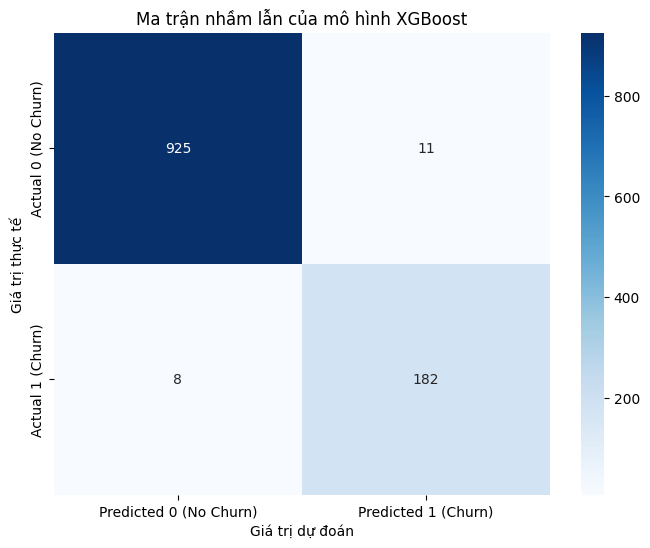

Độ chính xác của mô hình XGBoost: 0.9831
ROC AUC (XGBoost): 0.9959
PR AUC (XGBoost): 0.9796


/tmp/ipykernel_7701/48767858.py:73: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=f1_scores_xgb, palette='viridis')


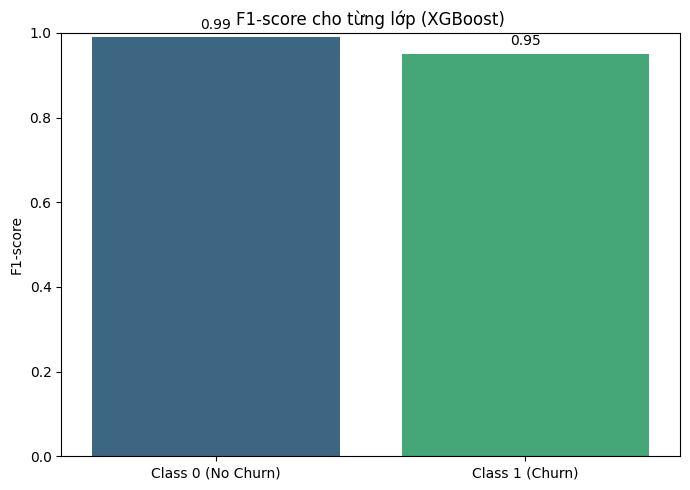

In [ ]:
import xgboost as xgb
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, f1_score, roc_auc_score, precision_recall_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

print("\n--- Huấn luyện mô hình XGBoost ---")
# Khởi tạo mô hình XGBoost Classifier
# scale_pos_weight có thể được dùng để xử lý mất cân bằng lớp thay cho SMOTE,
# nhưng vì đã dùng SMOTE nên ta để mặc định hoặc tính toán lại nếu cần.
xgb_model = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Bỏ cảnh báo về label encoder
    n_estimators=100,
    random_state=42,
    # scale_pos_weight = (count_negative_class / count_positive_class) nếu không dùng SMOTE
    # ví dụ: scale_pos_weight = y_train.value_counts()[0] / y_train.value_counts()[1]
)

# Huấn luyện mô hình trên dữ liệu đã được SMOTE
xgb_model.fit(X_train_res, y_train_res)

print("Mô hình XGBoost đã được huấn luyện thành công.")

# Lưu mô hình đã huấn luyện
xgb_model.save_model("xgboost_model.json")
print("Mô hình XGBoost đã được lưu vào xgboost_model.json")

print("\n--- Đánh giá mô hình XGBoost ---")
# Dự đoán trên tập kiểm thử
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1] # Xác suất cho lớp dương (Churn)

# In báo cáo phân loại
print("Báo cáo phân loại trên tập kiểm thử (XGBoost):")
report_xgb = classification_report(y_test, y_pred_xgb, output_dict=True)
print(classification_report(y_test, y_pred_xgb))

# In ma trận nhầm lẫn
print("Ma trận nhầm lẫn (XGBoost):")
cm_xgb = confusion_matrix(y_test, y_pred_xgb)
print(cm_xgb)

# Vẽ biểu đồ heatmap cho ma trận nhầm lẫn
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted 0 (No Churn)', 'Predicted 1 (Churn)'],
            yticklabels=['Actual 0 (No Churn)', 'Actual 1 (Churn)'])
plt.title('Ma trận nhầm lẫn của mô hình XGBoost')
plt.ylabel('Giá trị thực tế')
plt.xlabel('Giá trị dự đoán')
plt.show()

# In độ chính xác
accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"Độ chính xác của mô hình XGBoost: {accuracy_xgb:.4f}")

# Tính toán và in ROC AUC
roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"ROC AUC (XGBoost): {roc_auc_xgb:.4f}")

# Tính toán và in PR AUC
precision_xgb, recall_xgb, _ = precision_recall_curve(y_test, y_pred_proba_xgb)
pr_auc_xgb = auc(recall_xgb, precision_xgb)
print(f"PR AUC (XGBoost): {pr_auc_xgb:.4f}")

# Biểu đồ F1-score
f1_scores_xgb = [report_xgb['0']['f1-score'], report_xgb['1']['f1-score']]
labels = ['Class 0 (No Churn)', 'Class 1 (Churn)']

plt.figure(figsize=(7, 5))
sns.barplot(x=labels, y=f1_scores_xgb, palette='viridis')
plt.title('F1-score cho từng lớp (XGBoost)')
plt.ylabel('F1-score')
plt.ylim(0, 1)
for index, value in enumerate(f1_scores_xgb):
    plt.text(index, value + 0.02, f'{value:.2f}', ha='center')
plt.tight_layout()
plt.show()

# --- 8. Risk Tier Assignment — Chuyển hóa Dự đoán thành Hành động (Actionable Insights) ---
print("\n--- 8. Risk Tier Assignment ---")

# Tạo một DataFrame chứa CustomerID, Actual Churn và Predicted Churn Probability
# Đảm bảo CustomerID được lấy từ X_test để khớp với các dự đoán
churn_analysis_df = pd.DataFrame({
    'CustomerID': X_test['CustomerID'],
    'Actual_Churn': y_test,
    'Predicted_Churn_Probability': y_pred_proba_xgb
})

# 8.1. Phân loại Rủi ro (Risk Tiering)
def assign_risk_tier(prob):
    if prob > 0.7:
        return 'High Risk'
    elif 0.4 <= prob <= 0.69:
        return 'Medium Risk'
    else:
        return 'Low Risk'

churn_analysis_df['Risk_Tier'] = churn_analysis_df['Predicted_Churn_Probability'].apply(assign_risk_tier)

print("\nPhân phối khách hàng theo Risk Tier:")
print(churn_analysis_df['Risk_Tier'].value_counts())

print("\n5 dòng đầu tiên của DataFrame với Risk Tier:")
print(churn_analysis_df.head())

# Tùy chọn: Trực quan hóa phân phối Risk Tier
plt.figure(figsize=(8, 5))
sns.countplot(data=churn_analysis_df, x='Risk_Tier', order=['Low Risk', 'Medium Risk', 'High Risk'], palette='coolwarm')
plt.title('Phân phối khách hàng theo cấp độ rủi ro Churn')
plt.xlabel('Cấp độ rủi ro')
plt.ylabel('Số lượng khách hàng')
plt.tight_layout()
plt.show()


SHAP Summary Plot:


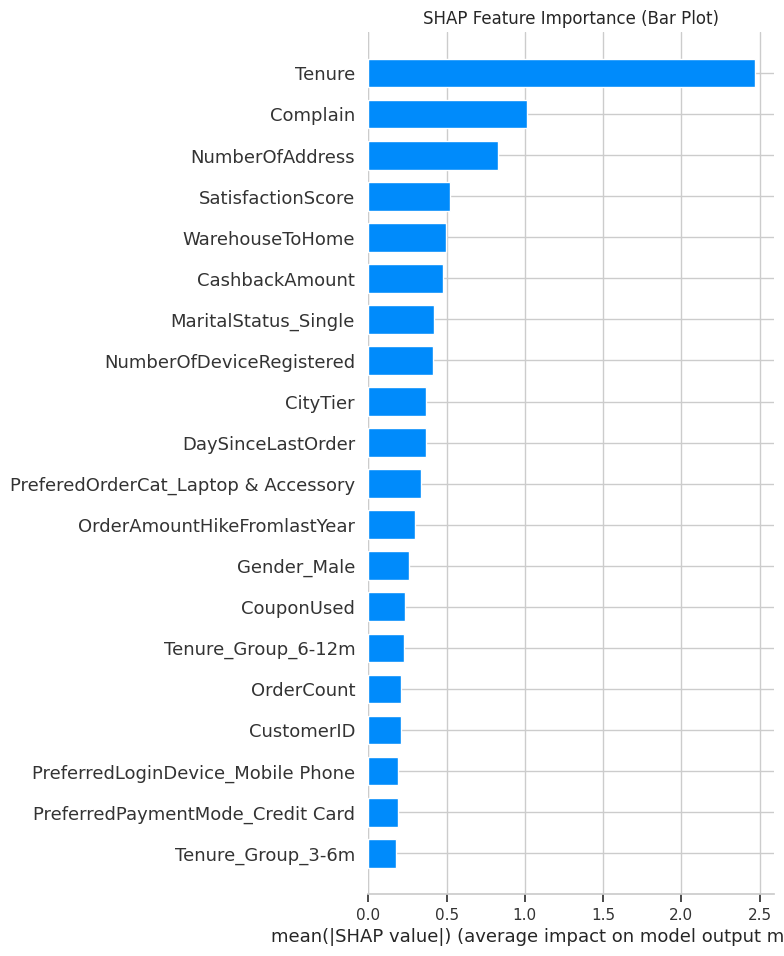

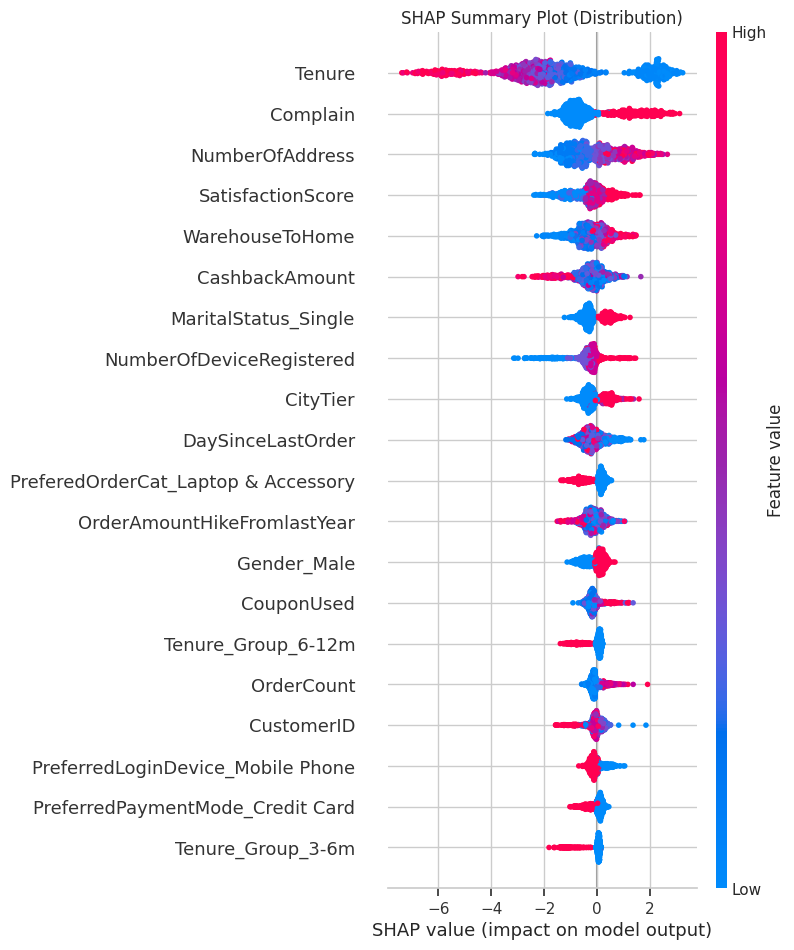


--- Bảng xếp hạng các đặc trưng theo giá trị SHAP trung bình tuyệt đối ---
                            Feature  Mean_Abs_SHAP_Value
                             Tenure             2.468018
                           Complain             1.016538
                    NumberOfAddress             0.828219
                  SatisfactionScore             0.523020
                    WarehouseToHome             0.493405
                     CashbackAmount             0.479033
               MaritalStatus_Single             0.417470
           NumberOfDeviceRegistered             0.412188
                           CityTier             0.367924
                  DaySinceLastOrder             0.366188
PreferedOrderCat_Laptop & Accessory             0.334412
        OrderAmountHikeFromlastYear             0.296043
                        Gender_Male             0.259781
                         CouponUsed             0.234866
                 Tenure_Group_6-12m             0.226315
            

In [ ]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# ── SHAP explainer trên XGBoost model ──
# Sử dụng mô hình XGBoost đã huấn luyện (xgb_model)
explainer = shap.TreeExplainer(xgb_model)

# Tính toán SHAP values trên tập kiểm thử (X_test)
# Chú ý: shap_values trả về một list nếu mô hình là multi-output hoặc tree-based đa class.
# Với binary classification, nó thường là một mảng 2D. shap_values[1] là cho class dương (Churn)
shap_values = explainer.shap_values(X_test)

# expected_value cho TreeExplainer thường là một giá trị duy nhất (base value)
base_val = explainer.expected_value

# --- Hiển thị SHAP Summary Plot ---
print("\nSHAP Summary Plot:")
# shap_values[1] thường là cho class dương (Churn=1) trong binary classification
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.title('SHAP Feature Importance (Bar Plot)')
plt.show()

shap.summary_plot(shap_values, X_test, show=False)
plt.title('SHAP Summary Plot (Distribution)')
plt.show()

# --- Chuyển SHAP values thành bảng số liệu ---
print("\n--- Bảng xếp hạng các đặc trưng theo giá trị SHAP trung bình tuyệt đối ---")

# Tính toán giá trị SHAP trung bình tuyệt đối cho từng đặc trưng
# Đối với binary classification, shap_values có thể là một list (shape (2, n_samples, n_features)) hoặc một array (shape (n_samples, n_features))
# Nếu là list, chúng ta lấy shap_values[1] cho lớp dương (Churn)
if isinstance(shap_values, list):
    # Take the SHAP values for the positive class (class 1 for 'Churn')
    mean_abs_shap_values = np.abs(shap_values[1]).mean(axis=0)
else:
    # If shap_values is already a single array (e.g., for single output models)
    mean_abs_shap_values = np.abs(shap_values).mean(axis=0)

# Tạo DataFrame
shap_importance_df = pd.DataFrame({
    'Feature': X_test.columns.tolist(),
    'Mean_Abs_SHAP_Value': mean_abs_shap_values
})

# Sắp xếp theo giá trị SHAP giảm dần
shap_importance_df = shap_importance_df.sort_values(by='Mean_Abs_SHAP_Value', ascending=False)

# In 20 đặc trưng quan trọng nhất
print(shap_importance_df.head(20).to_string(index=False))